In [77]:
import polars as pl
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#pl_df = pl.read_csv("../merged_dedup.csv")

In [78]:
pl_df = pl.read_csv("merged_dedup.csv")

In [3]:
keyword_counts = pl_df.with_columns(
    pl.col("Author Keywords")
        .str.split(";")
        .alias("Author Keywords")
).explode("Author Keywords").select(
    pl.col("Author Keywords")
        .str.strip_chars()  # Remove leading and trailing whitespace
        .str.to_lowercase()
        .value_counts(sort=True)
)

In [4]:
keyword_counts

Author Keywords
struct[2]
"{null,9535}"
"{""eeg"",5719}"
"{""electroencephalography"",2023}"
"{""electroencephalogram"",1259}"
"{""machine learning"",1249}"
…
"{""involuntary sleep"",1}"
"{""delay lines"",1}"
"{""floating gate transistor (fgmos)"",1}"


In [118]:
# Create a mapping dictionary for related terms
bci_mapping = {
    "bci": "brain-computer interface",
    "brain-computer interface (bci)": "brain-computer interface",
    "brain computer interface (bci)": "brain-computer interface",
    "brain computer interface": "brain-computer interface",
    "affective brain-computer interface": "brain-computer interface",
    "brain computer interface": "brain-computer interface", # Duplicate, but harmless
    "brain–computer interfaces": "brain-computer interface",
    "brain–computer interface": "brain-computer interface",
    "brain-computer interfaces": "brain-computer interface",
    "brain–computer interface (bci)":"brain-computer interface",

    "motor imagery (mi)": "motor imagery",
    "erp": "event-related potentials",
    "event-related potential": "event-related potentials",
    "steady-state visual evoked potential":"ssvep",
    "cnn": "convolutional neural network",
    "electrocardiography": "ecg",
    "electromyography":"emg",
    "eletromiography": "emg", # Typo: "eletromiography" -> "electromyography"
    "convolutional neural network (cnn)": "convolutional neural network",
    "convolutional neural networks": "convolutional neural network",
    "svm": "support vector machine",
    "ica": "independent component analysis",
    "independent component analysis (ica)": "independent component analysis",
    # "event-related potential": "event-related potentials", # Duplicate, but harmless
    "meg": "magnetoencephalography",
    "neuronal networks": "neural network",
    "neural networks": "neural network",
    "artifacts": "artifact removal",
    "emotion": "emotion recognition",
    "deep learning (dl)": "deep learning",
    "explainable artificial intelligence":"explainable ai",
}


# --- Updated Logic ---
# 1. Expand keywords and standardize them (lowercase, strip, apply mapping)
# 2. Filter out EEG-related terms
# 3. Group by the standardized keyword AND year to get counts
standardized_keyword_counts_by_year = pl_df.with_columns(
    pl.col("Author Keywords")
    .str.split(";")
    .alias("keyword_list") # Create a list of keywords
) \
.explode("keyword_list") \
.with_columns(
    pl.col("keyword_list")
    .str.strip_chars()      # Remove leading/trailing whitespace
    .str.to_lowercase()     # Convert to lowercase
    .alias("processed_keyword") # Temporary column for processing
) \
.filter(
    ~pl.col("processed_keyword").str.contains("(?i)eeg|electroencephalo") # Filter out EEG/electroencephalo
) \
.with_columns(
    pl.col("processed_keyword")
    .replace_strict(bci_mapping, default=pl.col("processed_keyword")) # Apply mapping
    .alias("standardized_word") # Final standardized keyword
) \
.group_by(["standardized_word", "Year"]) \
.agg(
    pl.count().alias("count") # Count occurrences for each standardized_word-Year pair
) \
.sort(["Year", "count"], descending=[False, True]) # Sort by year ascending, then count descending

print(standardized_keyword_counts_by_year)

group={
    "a":['brain-computer interface','virtual reality'],
    "b":['attention mechanism','lstm','data augmentation' ,'machine learning','deep learning','random forest','transformer','convolutional neural network','artificial intelligence','neural network','support vector machine (svm)','transfer learning'],
    'c':['motor imagery','event-related potentials','independent component analysis','support vector machine','functional connectivity','p300','wavelet transform','ssvep','common spatial pattern','source localization','mismatch negativity',"empirical mode decomposition"],
    'd':['epilepsy','schizophrenia','seizure detection','stroke','seizure','depression','epilepsy surgery'],
    'e':['emotion recognition','classification','attention','affective computing'],
    'f':['feature extraction','artifact removal','signal processing','feature selection','channel selection'],
    'g':['emg','ecg','magnetoencephalography','fmri','mri','physiological signals'],
    'h':['sleep','working memory','aging','brain','cognition','stress' ],
    'i':['neurofeedback','neuroscience','neuroimaging','neuromodulation'],
    'j':['rehabilitation'],
    }

# Flatten the dictionary into a list of (group, standardized_word) pairs
rows = [(k, v) for k, values in group.items() for v in values]
group_df = pl.DataFrame(rows, schema=["group","standardized_word"])

# Step 2: Join with your aggregated DataFrame
# Assuming filtered_eeg_df has a column 'standardized_word'
result = standardized_keyword_counts_by_year.join(group_df, on="standardized_word", how="left")
 
top50 = result.sort('count', descending=True).head(300)
top50 = top50.sort(["Year"], descending=[False])
top50 = top50.sort(["group"], descending=[False])
chart=alt.Chart(top50).mark_bar().encode(
    x=alt.X("standardized_word:N", sort=list(top50["standardized_word"])),
    y="count:Q",
    color="group:N",
    tooltip='Year',
    
)\
#.save('top50_words_chart.pdf')        

shape: (66_245, 3)
┌────────────────────────────────┬──────┬───────┐
│ standardized_word              ┆ Year ┆ count │
│ ---                            ┆ ---  ┆ ---   │
│ str                            ┆ i64  ┆ u32   │
╞════════════════════════════════╪══════╪═══════╡
│ brain-computer interface       ┆ 2014 ┆ 144   │
│ independent component analysis ┆ 2014 ┆ 68    │
│ event-related potentials       ┆ 2014 ┆ 68    │
│ epilepsy                       ┆ 2014 ┆ 62    │
│ magnetoencephalography         ┆ 2014 ┆ 35    │
│ …                              ┆ …    ┆ …     │
│ low dc offset                  ┆ 2025 ┆ 1     │
│ lightweight model              ┆ 2025 ┆ 1     │
│ augmented reality (ar)         ┆ 2025 ┆ 1     │
│ motor hemiplegia               ┆ 2025 ┆ 1     │
│ low rank subspace              ┆ 2025 ┆ 1     │
└────────────────────────────────┴──────┴───────┘


/tmp/ipykernel_25055/3380220993.py:64: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count") # Count occurrences for each standardized_word-Year pair
/tmp/ipykernel_25055/3380220993.py:85: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  group_df = pl.DataFrame(rows, schema=["group","standardized_word"])


In [6]:
chart

alt.Chart(...)


Top 5 emerging trends based on latest year's growth:
shape: (5, 6)
┌──────────────────────────┬──────┬───────┬───────┬─────────────────────┬───────────────────────┐
│ standardized_word        ┆ Year ┆ count ┆ group ┆ previous_year_count ┆ yearly_growth_percent │
│ ---                      ┆ ---  ┆ ---   ┆ ---   ┆ ---                 ┆ ---                   │
│ str                      ┆ i64  ┆ u32   ┆ str   ┆ u32                 ┆ f64                   │
╞══════════════════════════╪══════╪═══════╪═══════╪═════════════════════╪═══════════════════════╡
│ spatial filter           ┆ 2025 ┆ 1     ┆ null  ┆ 2                   ┆ 2.1475e11             │
│ singular value           ┆ 2025 ┆ 1     ┆ null  ┆ 2                   ┆ 2.1475e11             │
│ decomposition            ┆      ┆       ┆       ┆                     ┆                       │
│ erd/ers                  ┆ 2025 ┆ 1     ┆ null  ┆ 2                   ┆ 2.1475e11             │
│ sparse bayesian learning ┆ 2025 ┆ 1     ┆ null  

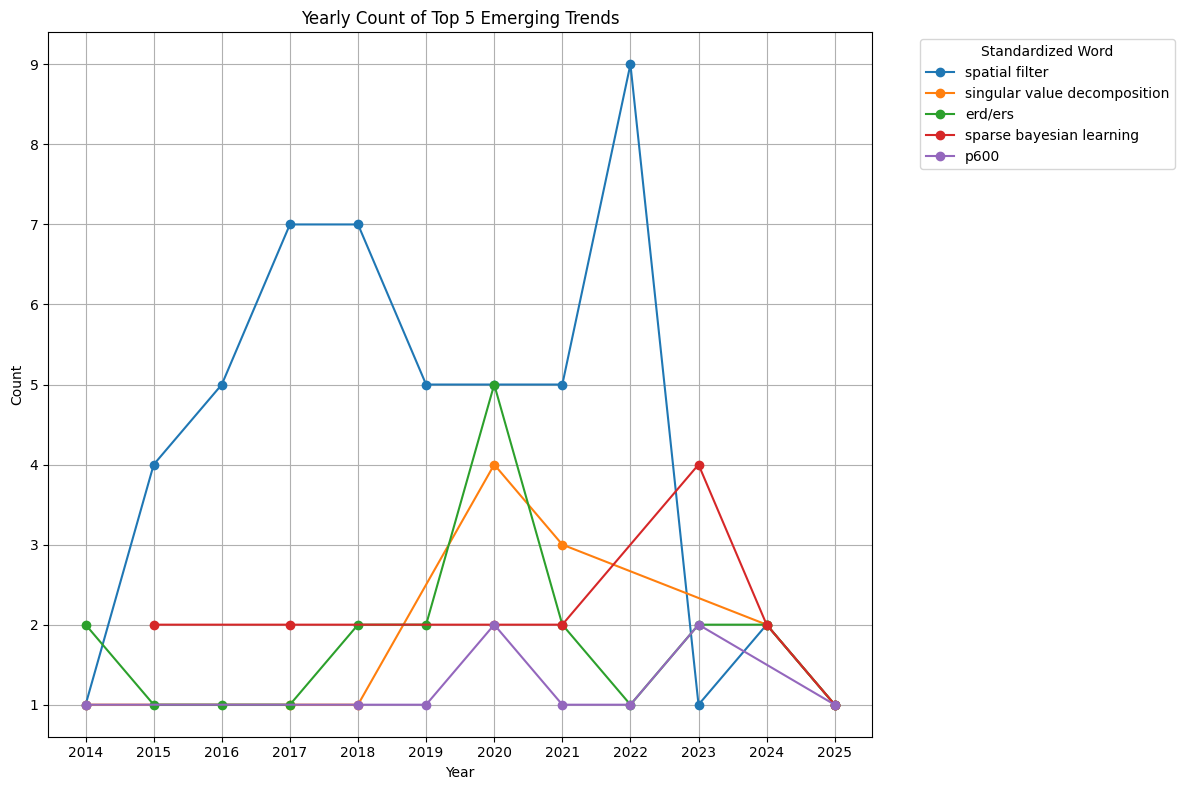

In [114]:
df_growth = result.with_columns(
    pl.col("count").shift(1).over("standardized_word").alias("previous_year_count")
)

# Calculate the growth percentage, handling the case where previous_year_count is 0 or null
df_growth = df_growth.with_columns(
    ((pl.col("count") - pl.col("previous_year_count")) / pl.col("previous_year_count") * 100)
    .alias("yearly_growth_percent")
)

# Filter out the first occurrence of each word, as it won't have a previous year's growth
df_growth = df_growth.filter(pl.col("previous_year_count").is_not_null())

# Identify emerging trends by looking at the latest year's growth.
latest_year = df_growth["Year"].max()
emerging_trends = df_growth.filter(pl.col("Year") == latest_year)
top_emerging_trends = emerging_trends.sort("yearly_growth_percent", descending=True)
top_emerging_trends_5 = top_emerging_trends.head(5)

print("\nTop 5 emerging trends based on latest year's growth:")
print(top_emerging_trends_5)

# Visualize the trends of the top 5 emerging words
top_words_to_plot = top_emerging_trends_5["standardized_word"].to_list()
df_to_plot = result.filter(pl.col("standardized_word").is_in(top_words_to_plot))

# Plotting
plt.figure(figsize=(12, 8))
for word in top_words_to_plot:
    word_data = df_to_plot.filter(pl.col("standardized_word") == word)
    plt.plot(word_data["Year"], word_data["count"], marker='o', label=word)

plt.title('Yearly Count of Top 5 Emerging Trends')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(df_to_plot["Year"].unique().sort())
plt.legend(title='Standardized Word', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('emerging_trends_growth.png')

In [119]:
import polars as pl
from math import log, exp
result = result.filter(pl.col('Year') != 2025)
# Assuming 'result' is your Polars DataFrame
# This code first groups by word and gets the first and last count and the total years.
cagr_data = result.sort("Year").group_by("standardized_word").agg(
    first_year_count = pl.col("count").first(),
    last_year_count = pl.col("count").last(),
    first_year = pl.col("Year").first(),
    last_year = pl.col("Year").last()
)

# Then, we calculate the CAGR
cagr_data = cagr_data.with_columns(
    years_diff = (pl.col("last_year") - pl.col("first_year")).cast(pl.Float64)
)

# The CAGR formula is ((End Value / Beginning Value)^(1/N)) - 1
# We handle the cases where there is only one year of data, or zero counts
cagr_data = cagr_data.with_columns(
    pl.when((pl.col("years_diff") > 0) & (pl.col("first_year_count") > 0))
    .then(
        (pl.col("last_year_count") / pl.col("first_year_count")).pow(1.0 / pl.col("years_diff")) - 1
    )
    .otherwise(pl.lit(None)) # Set to None if no growth can be calculated
    .alias("cagr_percent")
)

# Convert to percentage
cagr_data = cagr_data.with_columns(
    (pl.col("cagr_percent") * 100).alias("cagr_percent")
)
# Filter out the keywords that only appeared in a single year
significant_growing_trends = cagr_data.filter(
    (pl.col("years_diff") > 0) & (pl.col("last_year_count") >= 10)
)

# Sort by the CAGR to find the keywords with the most significant growth
top_emerging_trends_by_cagr = significant_growing_trends.sort("cagr_percent", descending=True)

# Print the top 20 trends to see if you get the expected results
print(top_emerging_trends_by_cagr.head(20))

shape: (20, 7)
┌───────────────┬──────────────┬──────────────┬────────────┬───────────┬────────────┬──────────────┐
│ standardized_ ┆ first_year_c ┆ last_year_co ┆ first_year ┆ last_year ┆ years_diff ┆ cagr_percent │
│ word          ┆ ount         ┆ unt          ┆ ---        ┆ ---       ┆ ---        ┆ ---          │
│ ---           ┆ ---          ┆ ---          ┆ i64        ┆ i64       ┆ f64        ┆ f64          │
│ str           ┆ u32          ┆ u32          ┆            ┆           ┆            ┆              │
╞═══════════════╪══════════════╪══════════════╪════════════╪═══════════╪════════════╪══════════════╡
│ contrastive   ┆ 2            ┆ 13           ┆ 2022       ┆ 2024      ┆ 2.0        ┆ 154.950976   │
│ learning      ┆              ┆              ┆            ┆           ┆            ┆              │
│ explainable   ┆ 2            ┆ 23           ┆ 2021       ┆ 2024      ┆ 3.0        ┆ 125.717872   │
│ ai            ┆              ┆              ┆            ┆           ┆    

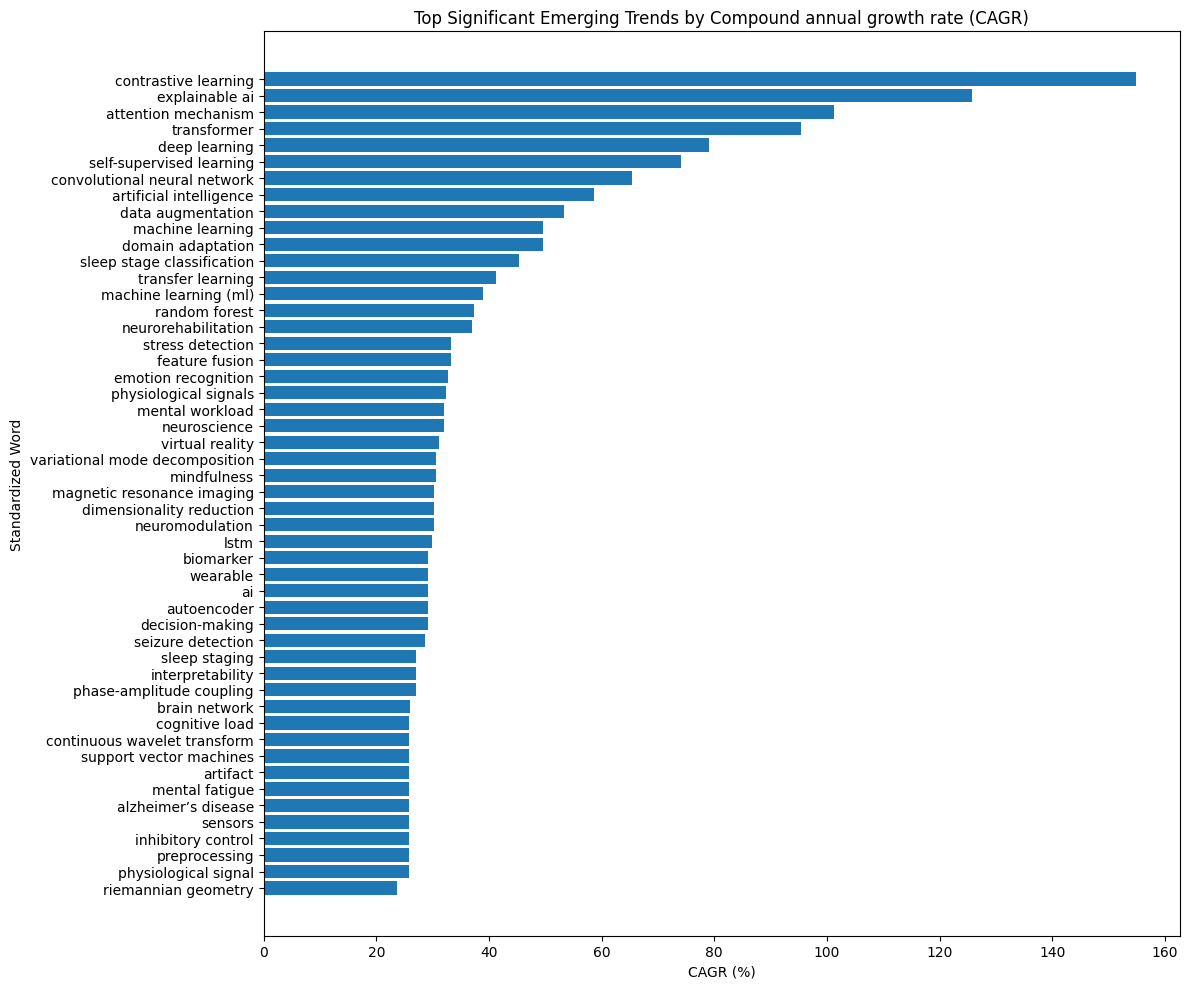

In [123]:
# Plot the data
plt.figure(figsize=(12, 10))
plt.barh(top_emerging_trends_by_cagr['standardized_word'].head(50), top_emerging_trends_by_cagr['cagr_percent'].head(50))
plt.xlabel('CAGR (%)')
plt.ylabel('Standardized Word')
plt.title('Top Significant Emerging Trends by Compound annual growth rate (CAGR)')
plt.gca().invert_yaxis() # To have the highest CAGR at the top
plt.tight_layout()
plt.savefig('top_trends_cagr.pdf')


In [105]:
print(top_emerging_trends_by_cagr.to_pandas().to_latex())

\begin{tabular}{llrrrrrr}
\toprule
 & standardized_word & first_year_count & last_year_count & first_year & last_year & years_diff & cagr_percent \\
\midrule
0 & explainable artificial intelligence & 3 & 13 & 2022 & 2024 & 2.000000 & 108.166600 \\
1 & explainable ai & 2 & 10 & 2021 & 2024 & 3.000000 & 70.997595 \\
2 & sleep stage classification & 1 & 20 & 2016 & 2024 & 8.000000 & 45.421543 \\
3 & machine learning (ml) & 1 & 10 & 2017 & 2024 & 7.000000 & 38.949549 \\
4 & random forest & 1 & 24 & 2014 & 2024 & 10.000000 & 37.410881 \\
5 & neurorehabilitation & 1 & 17 & 2015 & 2024 & 9.000000 & 36.998732 \\
6 & deep learning & 1 & 26 & 2014 & 2025 & 11.000000 & 34.472643 \\
7 & mindfulness & 1 & 11 & 2015 & 2024 & 9.000000 & 30.529988 \\
8 & magnetic resonance imaging & 1 & 14 & 2014 & 2024 & 10.000000 & 30.200545 \\
9 & wearable & 1 & 13 & 2014 & 2024 & 10.000000 & 29.239222 \\
10 & interpretability & 1 & 11 & 2014 & 2024 & 10.000000 & 27.098162 \\
11 & artifact & 1 & 10 & 2014 & 2024 & 

/tmp/ipykernel_25055/1760681760.py:33: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()
/tmp/ipykernel_25055/1760681760.py:41: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


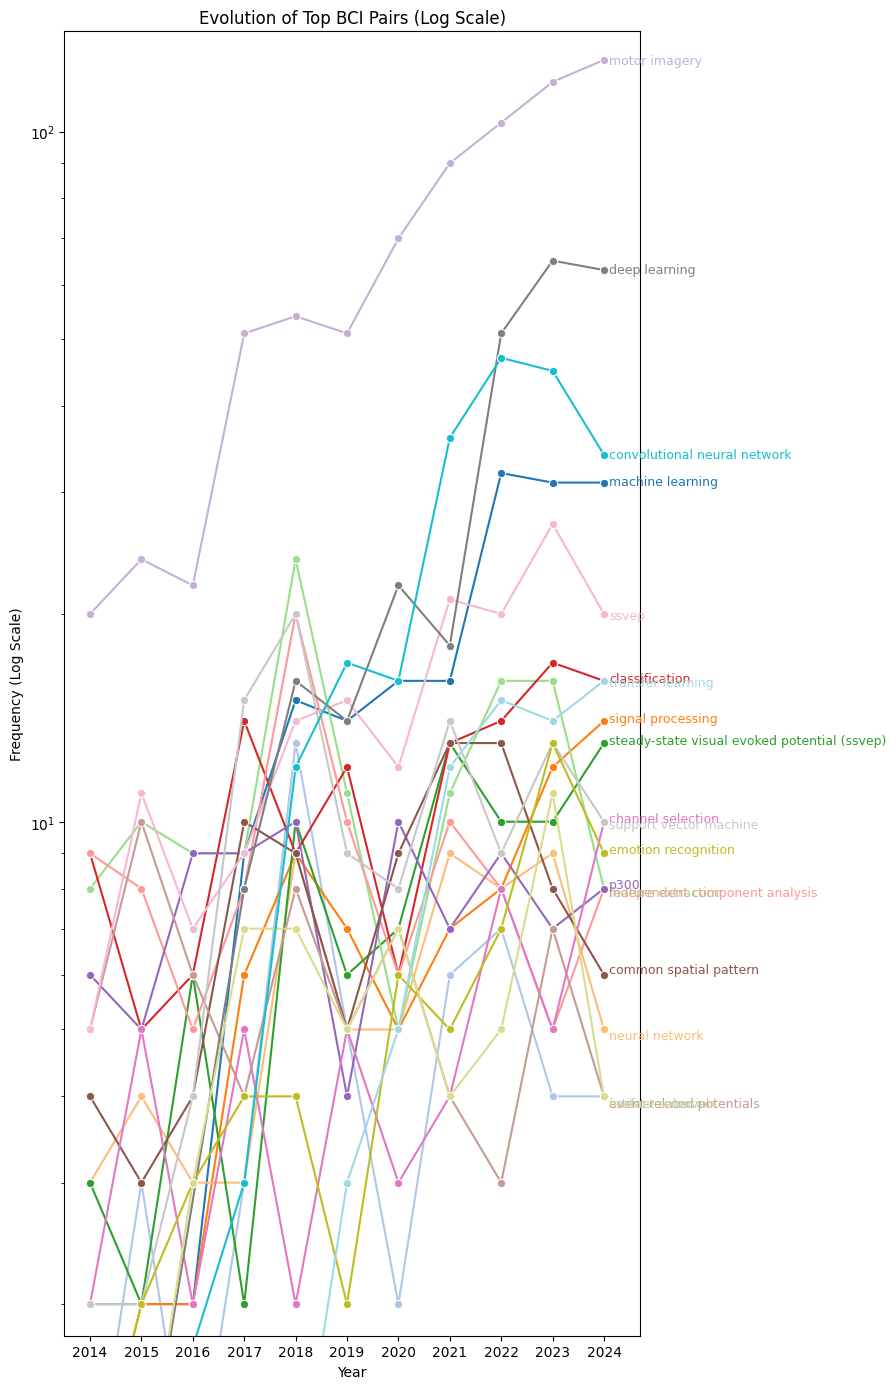

In [72]:
# Step 1: Standardize and explode keywords
df_keywords = (
    pl_df
    .with_columns(
        pl.col("Author Keywords").str.split(";").alias("Author Keywords")
    )
    .explode("Author Keywords")
    .with_columns(
        pl.col("Author Keywords")
            .str.strip_chars()
            .str.to_lowercase()
            .replace_strict(bci_mapping, default=pl.col("Author Keywords").str.to_lowercase().str.strip_chars())
            .alias("standardized_word")
    ).filter(
    ~pl.col("standardized_word").str.contains("(?i)eeg|electroencephalo") # Filter out EEG/electroencephalo
) 
)

# Step 2: Find titles with "brain-computer interface"
titles_with_bci = (
    df_keywords
    .filter(pl.col("standardized_word") == "brain-computer interface")
    .select("Title")
    .unique()
)

# Step 3: Filter to only those titles and count co-occurring standardized keywords
cooccurring = (
    df_keywords
    .join(titles_with_bci, on="Title")
    .filter(pl.col("standardized_word") != "brain-computer interface")
    .group_by("standardized_word")
    .count()
    .sort("count", descending=True)
)
cooccurring_by_year = (
    df_keywords
    .join(titles_with_bci, on="Title")
    .filter(pl.col("standardized_word") != "brain-computer interface")#mudar para ter o sem pair
    .group_by(["Year", "standardized_word"])
    .count()
    .sort(["Year", "count"], descending=[False, True])
)
top50 =cooccurring_by_year.sort('count', descending=True).head(300)
top50 = top50.sort(["Year"], descending=[False])
#top50 = top50.sort(["group"], descending=[False])

aggregated_counts = cooccurring_by_year.group_by(["Year", "standardized_word"]).agg(
    pl.col("count").sum().alias("total_count")
)

# Identify the most common terms across all years
top_terms = (
    aggregated_counts
    .group_by("standardized_word")
    .agg(pl.sum("total_count").alias("overall_count"))
    .sort("overall_count", descending=True)
    .head(20)  # Get top 20 terms
    .select("standardized_word")
)

# Convert the top_terms DataFrame to a list of strings for clearer use with is_in
top_terms_list = top_terms["standardized_word"].to_list()

# Filter the original data to include only these top terms and exclude 2025
# Convert to Pandas DataFrame for Seaborn plotting
plot_data_df = (
    aggregated_counts
    .filter(
        (pl.col("standardized_word").is_in(top_terms_list)) &
        (pl.col("Year") != 2025)
    )
    .sort("Year")  # Ensure data is sorted by year
    .to_pandas() # Convert Polars DataFrame to Pandas DataFrame for Seaborn
)

# --- Seaborn Plotting with Direct Labels and Log Scale ---

plt.figure(figsize=(9, 14))

# Get unique terms and generate a color palette
unique_terms = plot_data_df["standardized_word"].unique()
colors = sns.color_palette("tab20", n_colors=len(unique_terms))
color_map = dict(zip(unique_terms, colors))

# Plot each line and add text label
for i, term in enumerate(unique_terms):
    term_data = plot_data_df[plot_data_df["standardized_word"] == term]
    if not term_data.empty: # Ensure there's data for the term
        # Plot the line
        sns.lineplot(
            data=term_data,
            x="Year",
            y="total_count",
            color=color_map[term],
            marker="o",
            ax=plt.gca() # Plot on the current axes
        )

        # Get the last data point for labeling
        last_datapoint = term_data.iloc[-1]
        last_year = last_datapoint["Year"]
        last_count = last_datapoint["total_count"]

        # Add text label at the last data point
        if i % 2==0:
            plt.text(
                last_year + 0.1,  # Offset slightly to the right
                last_count +0.1,
                term,
                verticalalignment='center',
                fontsize=9,
                color=color_map[term]
            )
        else:
                plt.text(
                last_year + 0.1,  # Offset slightly to the right
                last_count - 0.1,
                term,
                verticalalignment='center',
                fontsize=9,
                color=color_map[term]
            )

# --- Apply Logarithmic Scale to Y-axis ---
plt.yscale('log') # This is the key change!

# Set plot titles and labels
plt.title("Evolution of Top BCI Pairs (Log Scale)")
plt.xlabel("Year")
plt.ylabel("Frequency (Log Scale)")

# Ensure x-axis ticks are integers for years
plt.xticks(plot_data_df["Year"].unique())

# Remove the default legend
#plt.legend().set_visible(False)

# Adjust plot limits for labels on the right
max_year = plot_data_df["Year"].max()
# For log scale, determine y-limits carefully. Ensure min_count is > 0.
min_count = plot_data_df["total_count"].min()
# If min_count is 0, a log scale will produce an error. You might need to handle this
# by adding a small constant or filtering out 0s if they exist.
if min_count == 0:
    print("Warning: Log scale applied with 0 values. Adjusting min_count to 1 for plotting.")
    # Option 1: Filter out rows where total_count is 0 before plotting
    # plot_data_df = plot_data_df[plot_data_df["total_count"] > 0]
    # Option 2: Set a floor for plotting purposes
    min_count = 1 # Or some small epsilon like 0.1

max_count = plot_data_df["total_count"].max()

plt.xlim(plot_data_df["Year"].min() - 0.5, max_year + 0.7) # Add some padding to the left and right
# For y-axis in log scale, it's often good to start just below min_count and end above max_count
plt.ylim(min_count * 1.8, max_count * 1.1) # Adjust these multipliers as needed for appearance


plt.tight_layout()
#plt.savefig("keywords_seaborn_labeled_logscale.pdf", bbox_inches='tight')
plt.savefig("BCI Pairs Linear.pdf", bbox_inches='tight')

# Display the plot
plt.show()




Dont recall but the below might be trash

In [48]:
# Identify the most common terms across all years
top_terms = (
    aggregated_counts
    .group_by("standardized_word")
    .agg(pl.sum("total_count").alias("overall_count"))
    .sort("overall_count", descending=True)
    .head(20)  # Get top 20 terms
    .select("standardized_word")
)
top_terms_list = top_terms["standardized_word"].to_list()

# Filter the original data to include only these top terms and exclude 2025
evolution_plot = (
    aggregated_counts
    .filter(
        (pl.col("standardized_word").is_in(top_terms_list)) &
        (pl.col("Year") != 2025)  # Exclude 2025
    )
    .sort("Year")  # Ensure data is sorted by year
    .plot.line(
        x="Year", 
        y="total_count", 
        color="standardized_word"
    )
    .properties(
        width=800,
        height=500,
        title="Evolution of Top Terms Over Time"
    )
    .configure_axisX(
        labelAngle=0,
        title="Year",
        format="d"  # Format as integer
    )
    .configure_axisY(
        title="Frequency"
    )
)

# Display the plot
#evolution_plot.save("keywords.pdf")

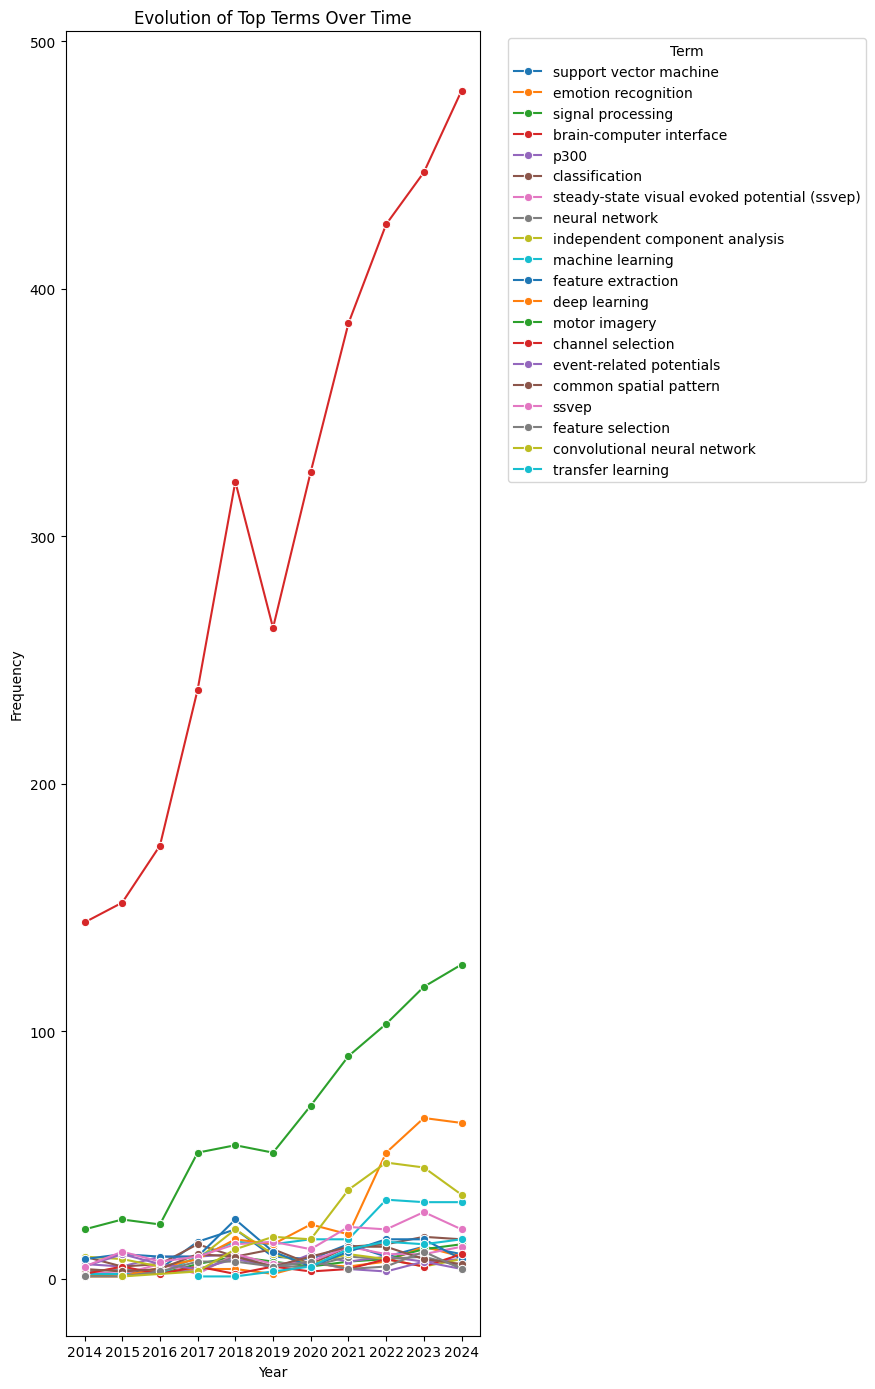

In [49]:

# Identify the most common terms across all years
top_terms = (
    aggregated_counts
    .group_by("standardized_word")
    .agg(pl.sum("total_count").alias("overall_count"))
    .sort("overall_count", descending=True)
    .head(20)  # Get top 20 terms
    .select("standardized_word")
)

# Convert the top_terms DataFrame to a list of strings for clearer use with is_in
top_terms_list = top_terms["standardized_word"].to_list()

# Filter the original data to include only these top terms and exclude 2025
# Convert to Pandas DataFrame for Seaborn plotting
plot_data_df = (
    aggregated_counts
    .filter(
        (pl.col("standardized_word").is_in(top_terms_list)) &
        (pl.col("Year") != 2025)
    )
    .sort("Year")  # Ensure data is sorted by year
    .to_pandas() # Convert Polars DataFrame to Pandas DataFrame for Seaborn
)

# --- Seaborn Plotting ---

plt.figure(figsize=(9, 14)) # Adjust figure size as needed

# Create the line plot using seaborn.lineplot
sns.lineplot(
    data=plot_data_df,
    x="Year",
    y="total_count",
    hue="standardized_word", # Use 'hue' to color lines by term
    marker="o", # Add markers for each data point (optional)
    palette="tab10" # Choose a color palette
)

# Set plot titles and labels
plt.title("Evolution of Top Terms Over Time")
plt.xlabel("Year")
plt.ylabel("Frequency")

# Ensure x-axis ticks are integers for years
plt.xticks(plot_data_df["Year"].unique())

# Add a legend for the terms
plt.legend(title="Term", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent labels/legend from overlapping
plt.tight_layout()

# Display the plot
plt.show()

# To save the plot (uncomment if needed)
# plt.savefig("keywords_seaborn.pdf")


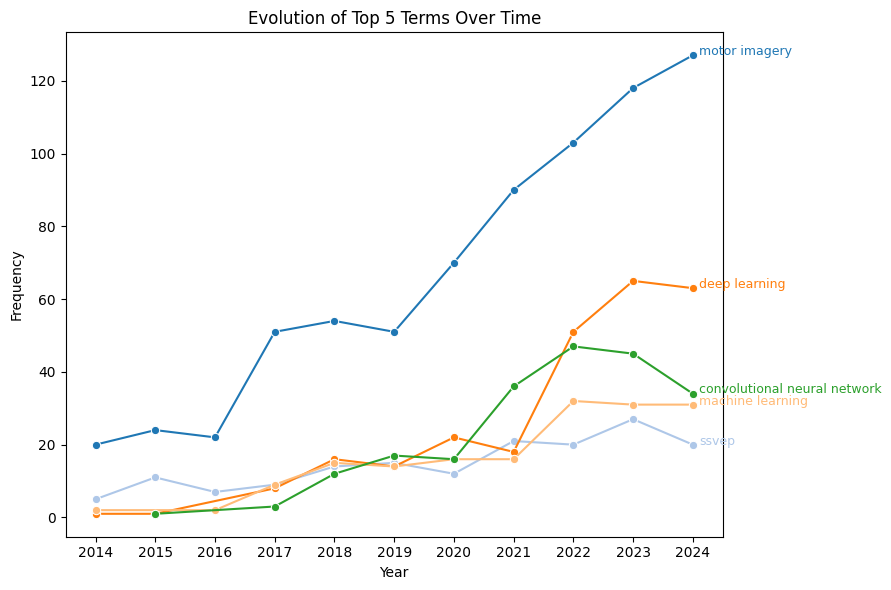

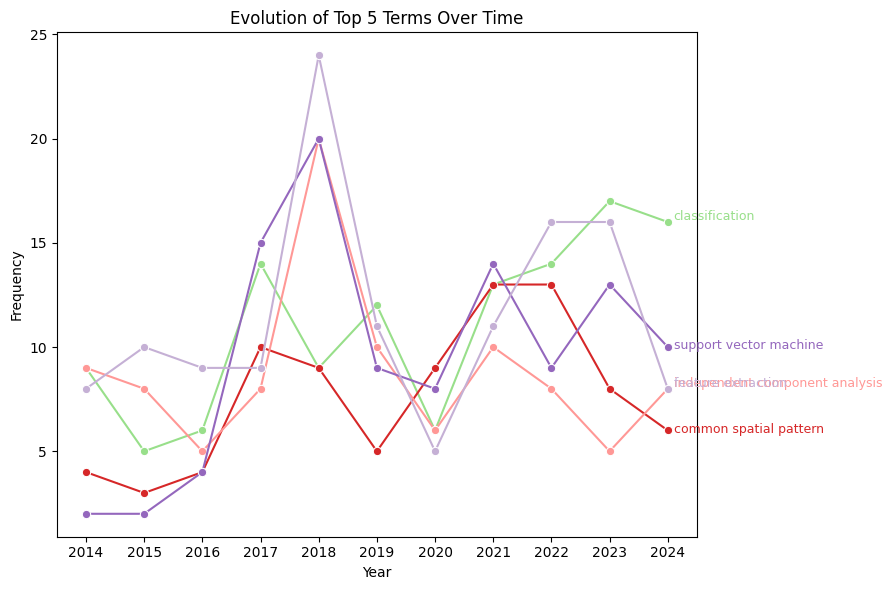

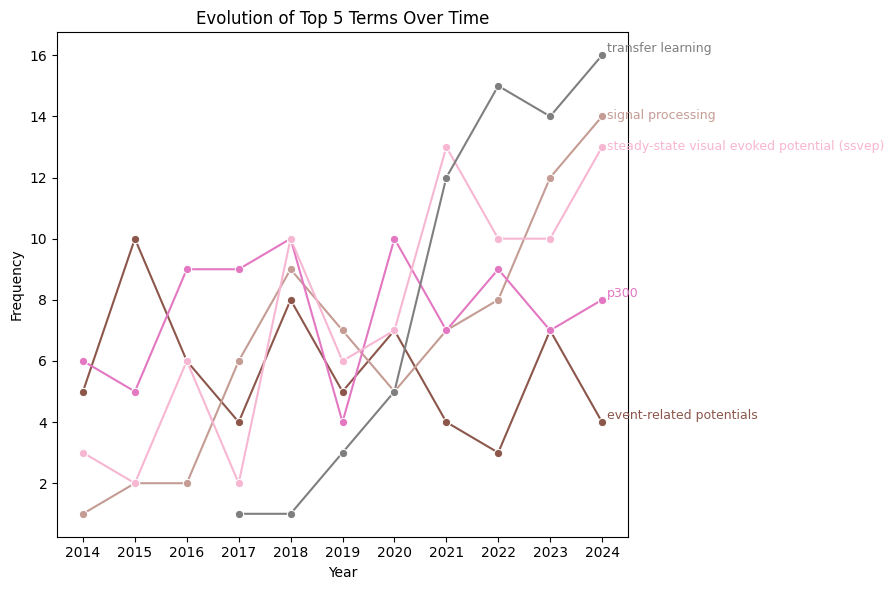

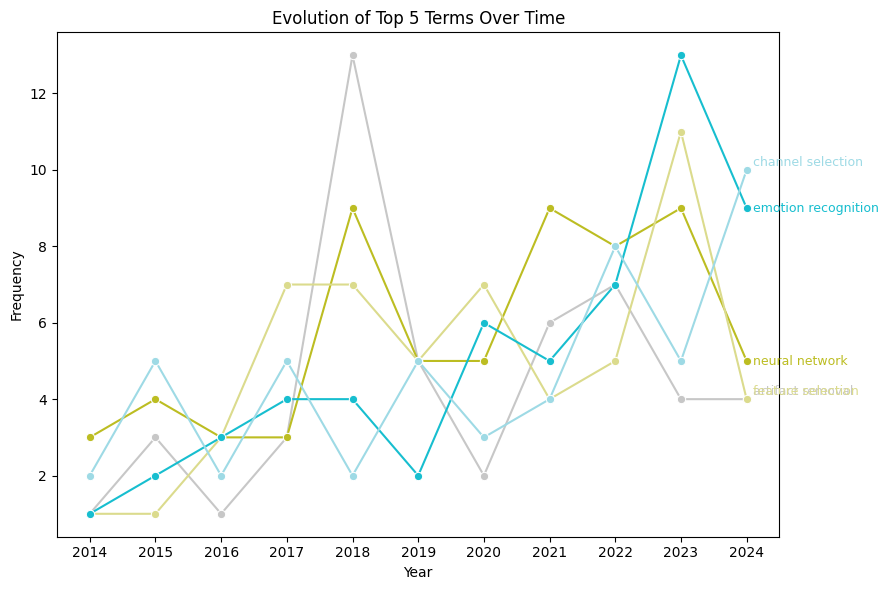

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate one 20-color palette for both graphs
all_colors = sns.color_palette("tab20", n_colors=20)
step=5

for i in range(4):
    top_terms_5 = top_terms["standardized_word"][i*5:(i+1)*5].to_list()
    
    plot_data_df_5 = (
        aggregated_counts
        .filter(
            (pl.col("standardized_word").is_in(top_terms_5)) &
            (pl.col("Year") != 2025)
        )
        .sort("Year")
        .to_pandas()
    )
    
    plt.figure(figsize=(9, 6))
    
    unique_terms_5 = plot_data_df_5["standardized_word"].unique()
    color_map_5 = dict(zip(unique_terms_5, all_colors[i*5:(i+1)*5]))  # first 5 unique colors
    
    for i, term in enumerate(unique_terms_5):
        term_data = plot_data_df_5[plot_data_df_5["standardized_word"] == term]
        if not term_data.empty:
            sns.lineplot(
                data=term_data,
                x="Year",
                y="total_count",
                color=color_map_5[term],
                marker="o"
            )
            last_datapoint = term_data.iloc[-1]
            plt.text(
                last_datapoint["Year"] + 0.1,
                last_datapoint["total_count"] + (0.1 if i % 2 == 0 else -0.1),
                term,
                fontsize=9,
                color=color_map_5[term]
            )
    
    plt.title("Evolution of Top 5 Terms Over Time")
    plt.xlabel("Year")
    plt.ylabel("Frequency")
    plt.xticks(plot_data_df_5["Year"].unique())
    plt.tight_layout()
    plt.savefig("keywords_top5.pdf", bbox_inches='tight')
    plt.show()





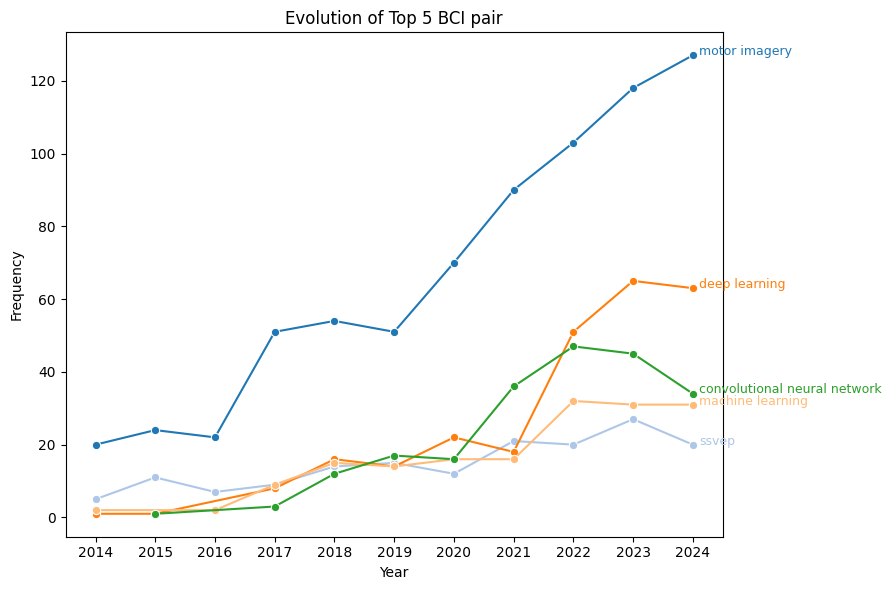

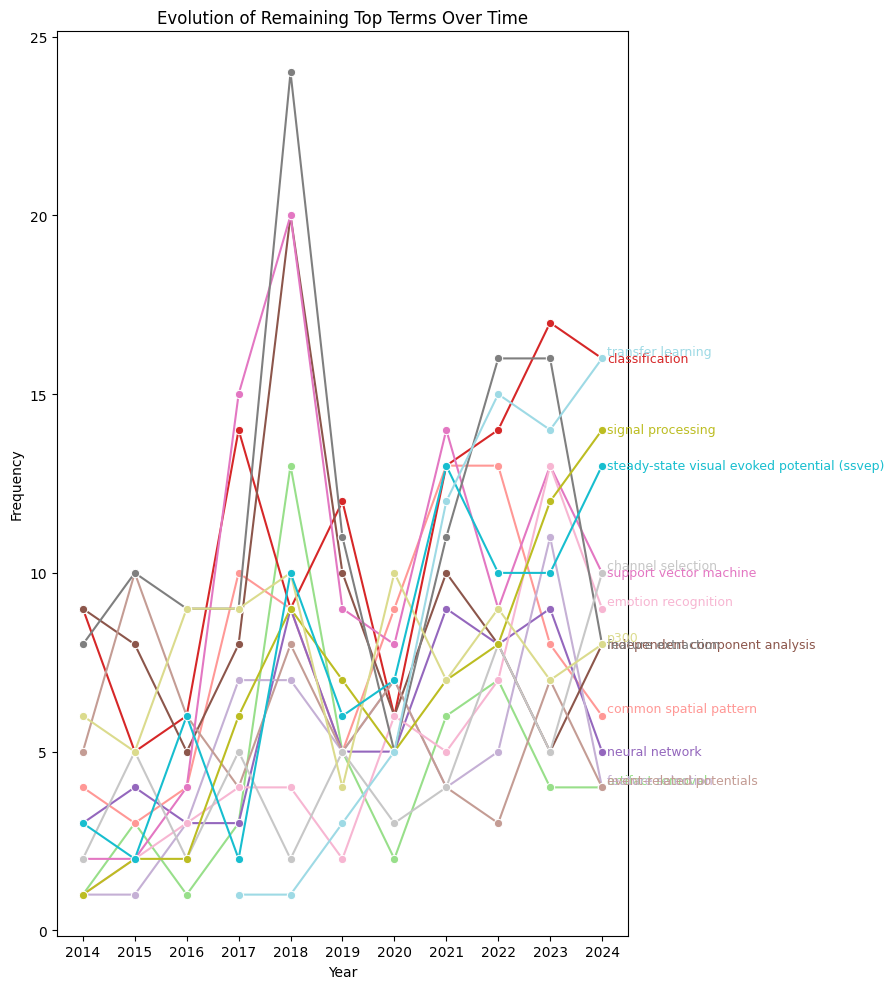

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate one 20-color palette for both graphs
all_colors = sns.color_palette("tab20", n_colors=20)

# -------------------------
# First plot: Top 5 terms
# -------------------------
top_terms_5 = top_terms["standardized_word"][:5].to_list()

plot_data_df_5 = (
    aggregated_counts
    .filter(
        (pl.col("standardized_word").is_in(top_terms_5)) &
        (pl.col("Year") != 2025)
    )
    .sort("Year")
    .to_pandas()
)

plt.figure(figsize=(9, 6))

unique_terms_5 = plot_data_df_5["standardized_word"].unique()
color_map_5 = dict(zip(unique_terms_5, all_colors[:5]))  # first 5 unique colors

for i, term in enumerate(unique_terms_5):
    term_data = plot_data_df_5[plot_data_df_5["standardized_word"] == term]
    if not term_data.empty:
        sns.lineplot(
            data=term_data,
            x="Year",
            y="total_count",
            color=color_map_5[term],
            marker="o"
        )
        last_datapoint = term_data.iloc[-1]
        plt.text(
            last_datapoint["Year"] + 0.1,
            last_datapoint["total_count"] + (0.1 if i % 2 == 0 else -0.1),
            term,
            fontsize=9,
            color=color_map_5[term]
        )

plt.title("Evolution of Top 5 BCI pair")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.xticks(plot_data_df_5["Year"].unique())
plt.tight_layout()
plt.savefig("keywords_top5.pdf", bbox_inches='tight')
plt.show()


# -------------------------
# Second plot: Remaining terms (6-20)
# -------------------------
top_terms_rest = top_terms["standardized_word"][5:].to_list()

plot_data_df_rest = (
    aggregated_counts
    .filter(
        (pl.col("standardized_word").is_in(top_terms_rest)) &
        (pl.col("Year") != 2025)
    )
    .sort("Year")
    .to_pandas()
)

plt.figure(figsize=(9, 10))

unique_terms_rest = plot_data_df_rest["standardized_word"].unique()
color_map_rest = dict(zip(unique_terms_rest, all_colors[5:]))  # remaining 15 unique colors

for i, term in enumerate(unique_terms_rest):
    term_data = plot_data_df_rest[plot_data_df_rest["standardized_word"] == term]
    if not term_data.empty:
        sns.lineplot(
            data=term_data,
            x="Year",
            y="total_count",
            color=color_map_rest[term],
            marker="o"
        )
        last_datapoint = term_data.iloc[-1]
        plt.text(
            last_datapoint["Year"] + 0.1,
            last_datapoint["total_count"] + (0.1 if i % 2 == 0 else -0.1),
            term,
            fontsize=9,
            color=color_map_rest[term]
        )

plt.title("Evolution of Remaining Top Terms Over Time")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.xticks(plot_data_df_rest["Year"].unique())
plt.tight_layout()
plt.savefig("keywords_remaining.pdf", bbox_inches='tight')
plt.show()


True


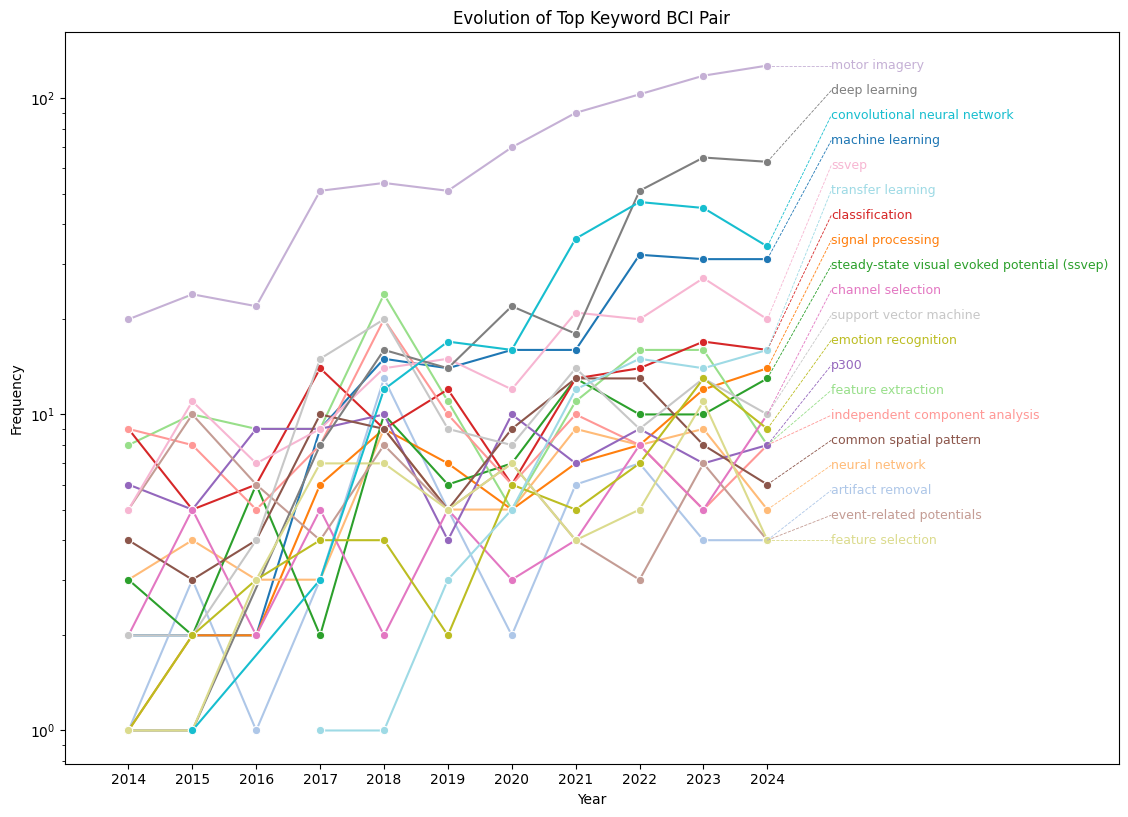

In [76]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(11.69,8.27))

unique_terms = plot_data_df["standardized_word"].unique()
colors = sns.color_palette("tab20", n_colors=len(unique_terms))
color_map = dict(zip(unique_terms, colors))

# Plot the lines
for term in unique_terms:
    sns.lineplot(
        data=plot_data_df[plot_data_df["standardized_word"] == term],
        x="Year",
        y="total_count",
        color=color_map[term],
        marker="o",
        ax=plt.gca()
    )


# Adjust axes
plt.yscale('log')
plt.title("Evolution of Top Keyword BCI Pair")
plt.xlabel("Year")
plt.ylabel("Frequency")
# Create evenly spaced label Y positions
if plt.gca().get_yscale() == "log":
    print("True")
    stack_positions = np.exp(np.linspace(
        np.log(subset_sorted["total_count"].min()),
        np.log(subset_sorted["total_count"].max()),
        len(subset_sorted)
    ))
else:
    stack_positions = np.linspace(
        subset_sorted["total_count"].min(),
        subset_sorted["total_count"].max(),
        len(subset_sorted)
    )
# Year where labels will be placed (choose first or last)
label_year = plot_data_df["Year"].max()
subset = plot_data_df[plot_data_df["Year"] == label_year]

# Sort terms by value for stacking
subset_sorted = subset.sort_values("total_count", ascending=True)


# Plot stacked labels in a column
for (term, row), y_pos in zip(subset_sorted.iterrows(), stack_positions):
    x_label = label_year + 1  # offset column to the right
    plt.text(
        x_label,
        y_pos,
        row["standardized_word"],
        fontsize=9,
        color=color_map[row["standardized_word"]],
        ha='left',
        va='center'
    )
    # optional: draw a connector line
    plt.plot(
        [label_year, x_label],
        [row["total_count"], y_pos],
        color=color_map[row["standardized_word"]],
        linestyle="--",
        linewidth=0.6
    )

plt.gca().yaxis.tick_left()
plt.gca().yaxis.set_label_position("left")
plt.xticks(plot_data_df["Year"].unique())

plt.xlim(plot_data_df["Year"].min() - 1, label_year + 5.5)
plt.tight_layout()
plt.savefig("keywords_seaborn.pdf")
plt.show()


In [44]:
top50

Year,standardized_word,count
i64,str,u32
2014,"""motor imagery""",20
2014,"""classification""",9
2014,"""independent component analysis""",9
2014,"""feature extraction""",8
2014,"""p300""",6
…,…,…
2024,"""emg""",5
2025,"""motor imagery""",17
2025,"""deep learning""",6


<Figure size 1200x600 with 0 Axes>

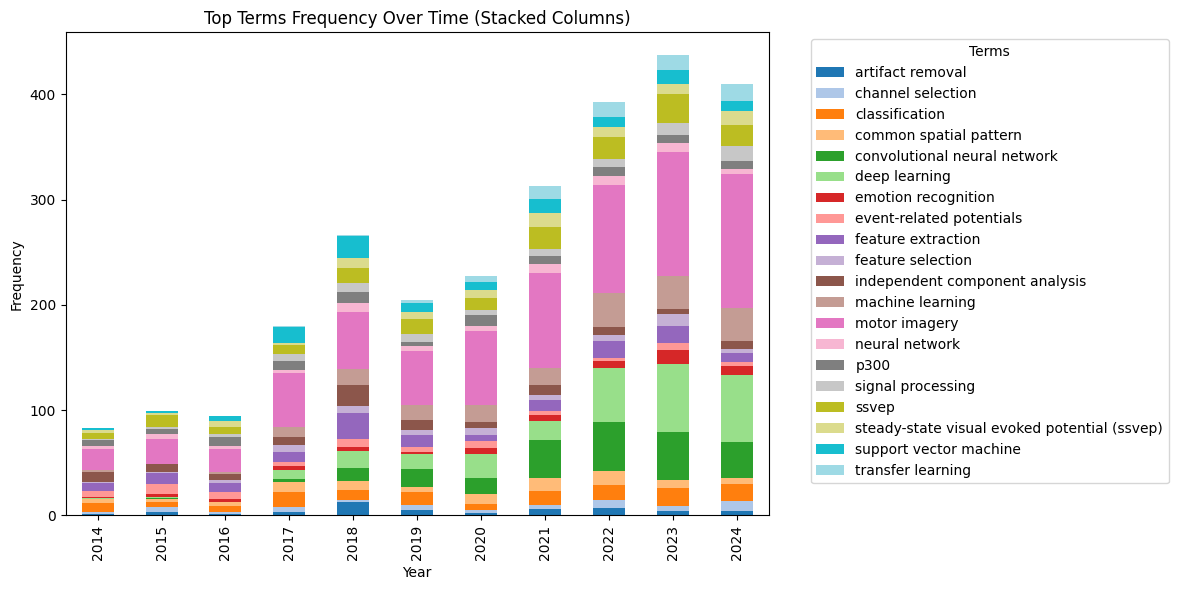

In [22]:
plt.figure(figsize=(12, 6))

# Pivot data for stacked bar plotting
pivot_df = plot_data_df.pivot_table(
    index="Year",
    columns="standardized_word",
    values="total_count",
    fill_value=0
)

# Plot stacked bar chart
pivot_df.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")

plt.title("Top Terms Frequency Over Time (Stacked Columns)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(title="Terms", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


AI SPACY

In [63]:
import spacy
import polars as pl
from collections import Counter
spacy.prefer_gpu()
nlp = spacy.load("en_core_web_trf")

In [ ]:
pl_df = pl.read_csv("merged_dedup.csv")

In [ ]:
doc=nlp(pl_df["Abstract"][0])
meaningful_tokens = [
    token.lemma_.lower() for token in doc
    if not token.is_stop and not token.is_punct and not token.is_space and
        token.pos_ in ['NOUN', 'PROPN', 'ADJ', 'VERB']
]
meaningful_tokens

In [4]:
def analyze_abstract_spacy(abstract_text, num_common_words=10, num_common_phrases=5):
    """
    Analyzes an abstract using spaCy to extract key information.

    Args:
        abstract_text (str): The input abstract string.
        num_common_words (int): Number of most common non-stopword nouns/adjectives/verbs.
        num_common_phrases (int): Number of most common noun chunks.

    Returns:
        dict: A dictionary containing extracted information.
    """
    doc = nlp(abstract_text)

    # --- 1. Get Most Common Words (filtered for key parts of speech and stopwords) ---
    # Filter out stopwords, punctuation, and spaces.
    # Focus on nouns, proper nouns, adjectives, and verbs as they carry more meaning.
    meaningful_tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space and
           token.pos_ in ['NOUN', 'PROPN', 'ADJ', 'VERB']
    ]
    most_common_words = Counter(meaningful_tokens).most_common(num_common_words)

    # --- 2. Extract Named Entities (NER) ---
    # Named entities are real-world objects like persons, organizations, locations, etc.
    # These can highlight key actors, technologies, or places mentioned.
    named_entities = []
    for ent in doc.ents:
        if ent.label_ == "ORG": # Add this condition
            named_entities.append(ent.text)
    
    # Optional: Group entities by label for better readability
    entities_by_label = Counter([ent.label_ for ent in doc.ents])
    
    # --- 3. Extract Noun Chunks (Candidate Keyphrases) ---
    # Noun chunks are phrases that have a noun as their head. They often represent key concepts.
    noun_chunks = [chunk.text.lower() for chunk in doc.noun_chunks]
    most_common_noun_chunks = Counter(noun_chunks).most_common(num_common_phrases)

    # --- 4. Identify Potential Subjects/Objects (Dependency Parsing - more advanced) ---
    # This can help infer relationships between concepts.
    # For a simple abstract, we might just look for main subjects.
    main_subjects = []
    for token in doc:
        # A simple heuristic: find nouns that are subjects of verbs
        if "subj" in token.dep_ and token.pos_ in ['NOUN', 'PROPN']:
            main_subjects.append(token.text.lower())
    main_subjects_unique = list(set(main_subjects)) # Unique subjects

    return meaningful_tokens,named_entities,noun_chunks,main_subjects_unique

    

In [61]:
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm import tqdm
counter=0
total_abstracts=len(pl_df)
batch = []
schema={"meaningful_tokens":pl.List(pl.String), "entities":pl.List(pl.String), "noun_chunks":pl.List(pl.String), "main_subjects_unique":pl.List(pl.String)}
results_lm=pl.DataFrame(schema=schema)
with tqdm(total=total_abstracts) as progress_bar:
    for i in pl_df.iter_rows():

        meaningful_tokens, entities,noun_chunks, main_subjects_unique= analyze_abstract_spacy(str(i[1])) 
        new_row={"meaningful_tokens": meaningful_tokens, "entities":entities, "noun_chunks":noun_chunks, "main_subjects_unique":main_subjects_unique}   
        batch.append(new_row)
        if counter%1000==0:
            df_temp=pl.DataFrame(batch,schema=schema,strict=False)
            results_lm.extend(df_temp)
            batch=[] 
        progress_bar.update(1) # update progress
        counter+=1
        #if counter==33927:
            #break


100%|██████████| 33927/33927 [26:02<00:00, 21.71it/s]


In [71]:
results_lm.write_parquet("results_lm")

In [4]:
results_lm=pl.read_parquet("results_lm")

In [5]:
results_lm.columns

['meaningful_tokens', 'entities', 'noun_chunks', 'main_subjects_unique']

In [6]:
def count_list_column_items(df: pl.DataFrame, column_name: str) -> pl.DataFrame:
    """
    Counts the occurrences of each item within a list column across all rows.
    Returns a DataFrame with 'item' and 'count' columns.
    """
    return (
        df.lazy()
        .select(
            pl.col(column_name).explode().alias("item") # Explode flattens the lists into individual rows
        )
        .group_by("item")
        .len() # Count occurrences
        .sort("len", descending=True)
        .collect()
    )
with pl.Config(tbl_rows=20):
    print("--- Meaningful Tokens Frequencies ---")
    meaningful_token_counts = count_list_column_items(results_lm, "meaningful_tokens").filter(
        (~pl.col("item").str.contains(r"[@©\-_|]")) &
        (pl.col("item") != "null") &
        (pl.col("item").is_not_null())
    )
    print(meaningful_token_counts.head(20))

    print("\n--- Entities Frequencies ---")
    entity_counts = count_list_column_items(results_lm, "entities").filter(
        (~pl.col("item").str.contains(r"[@©\-_|]")) &
        (pl.col("item") != "null") &
        (pl.col("item").is_not_null())
    )
    print(entity_counts.head(20))

    print("\n--- Noun Chunks Frequencies ---")
    noun_chunk_counts = count_list_column_items(results_lm, "noun_chunks").filter(
        (~pl.col("item").str.contains(r"[@©\-_|]")) &
        (pl.col("item") != "null") &
        (pl.col("item").is_not_null())
    )
    print(noun_chunk_counts.head(20))

    print("\n--- Main Subjects Frequencies ---")
    main_subject_counts = count_list_column_items(results_lm, "main_subjects_unique")
    print(main_subject_counts.head(20))


--- Meaningful Tokens Frequencies ---
shape: (20, 2)
┌────────────────┬───────┐
│ item           ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ eeg            ┆ 71291 │
│ signal         ┆ 44510 │
│ method         ┆ 31747 │
│ brain          ┆ 31689 │
│ study          ┆ 28123 │
│ result         ┆ 28061 │
│ feature        ┆ 25202 │
│ base           ┆ 23962 │
│ datum          ┆ 22287 │
│ propose        ┆ 20987 │
│ model          ┆ 19778 │
│ time           ┆ 19553 │
│ patient        ┆ 19101 │
│ activity       ┆ 18607 │
│ high           ┆ 18338 │
│ neural         ┆ 18121 │
│ analysis       ┆ 17665 │
│ accuracy       ┆ 17298 │
│ classification ┆ 16845 │
│ system         ┆ 16678 │
└────────────────┴───────┘

--- Entities Frequencies ---
shape: (20, 2)
┌─────────────────────────────────┬──────┐
│ item                            ┆ len  │
│ ---                             ┆ ---  │
│ str                             ┆ u32  │
╞═══════════════════════════

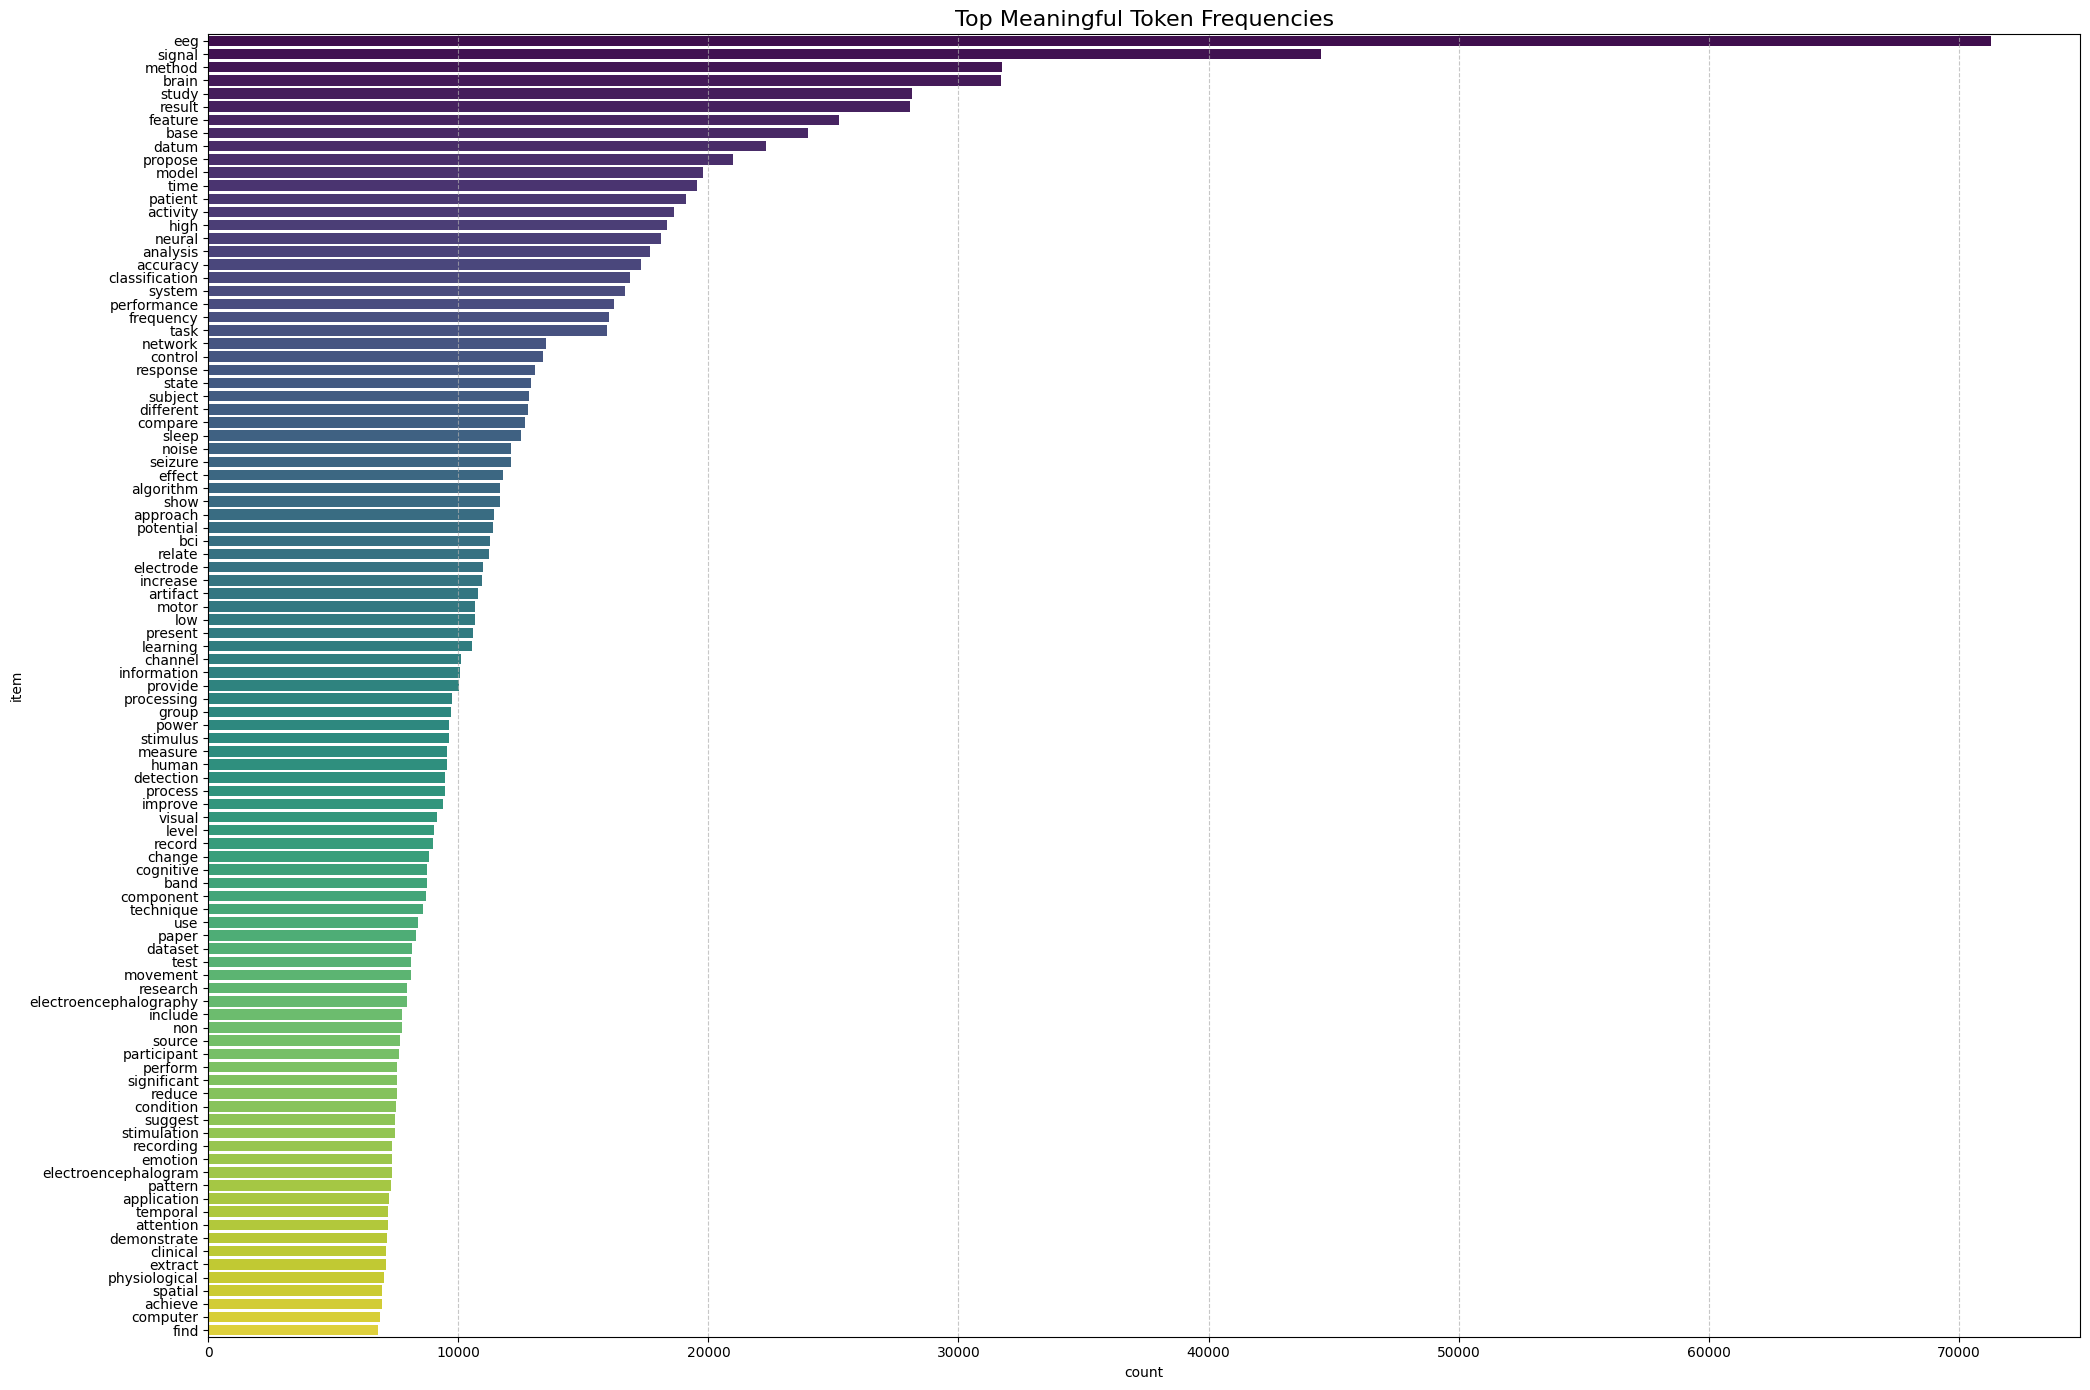

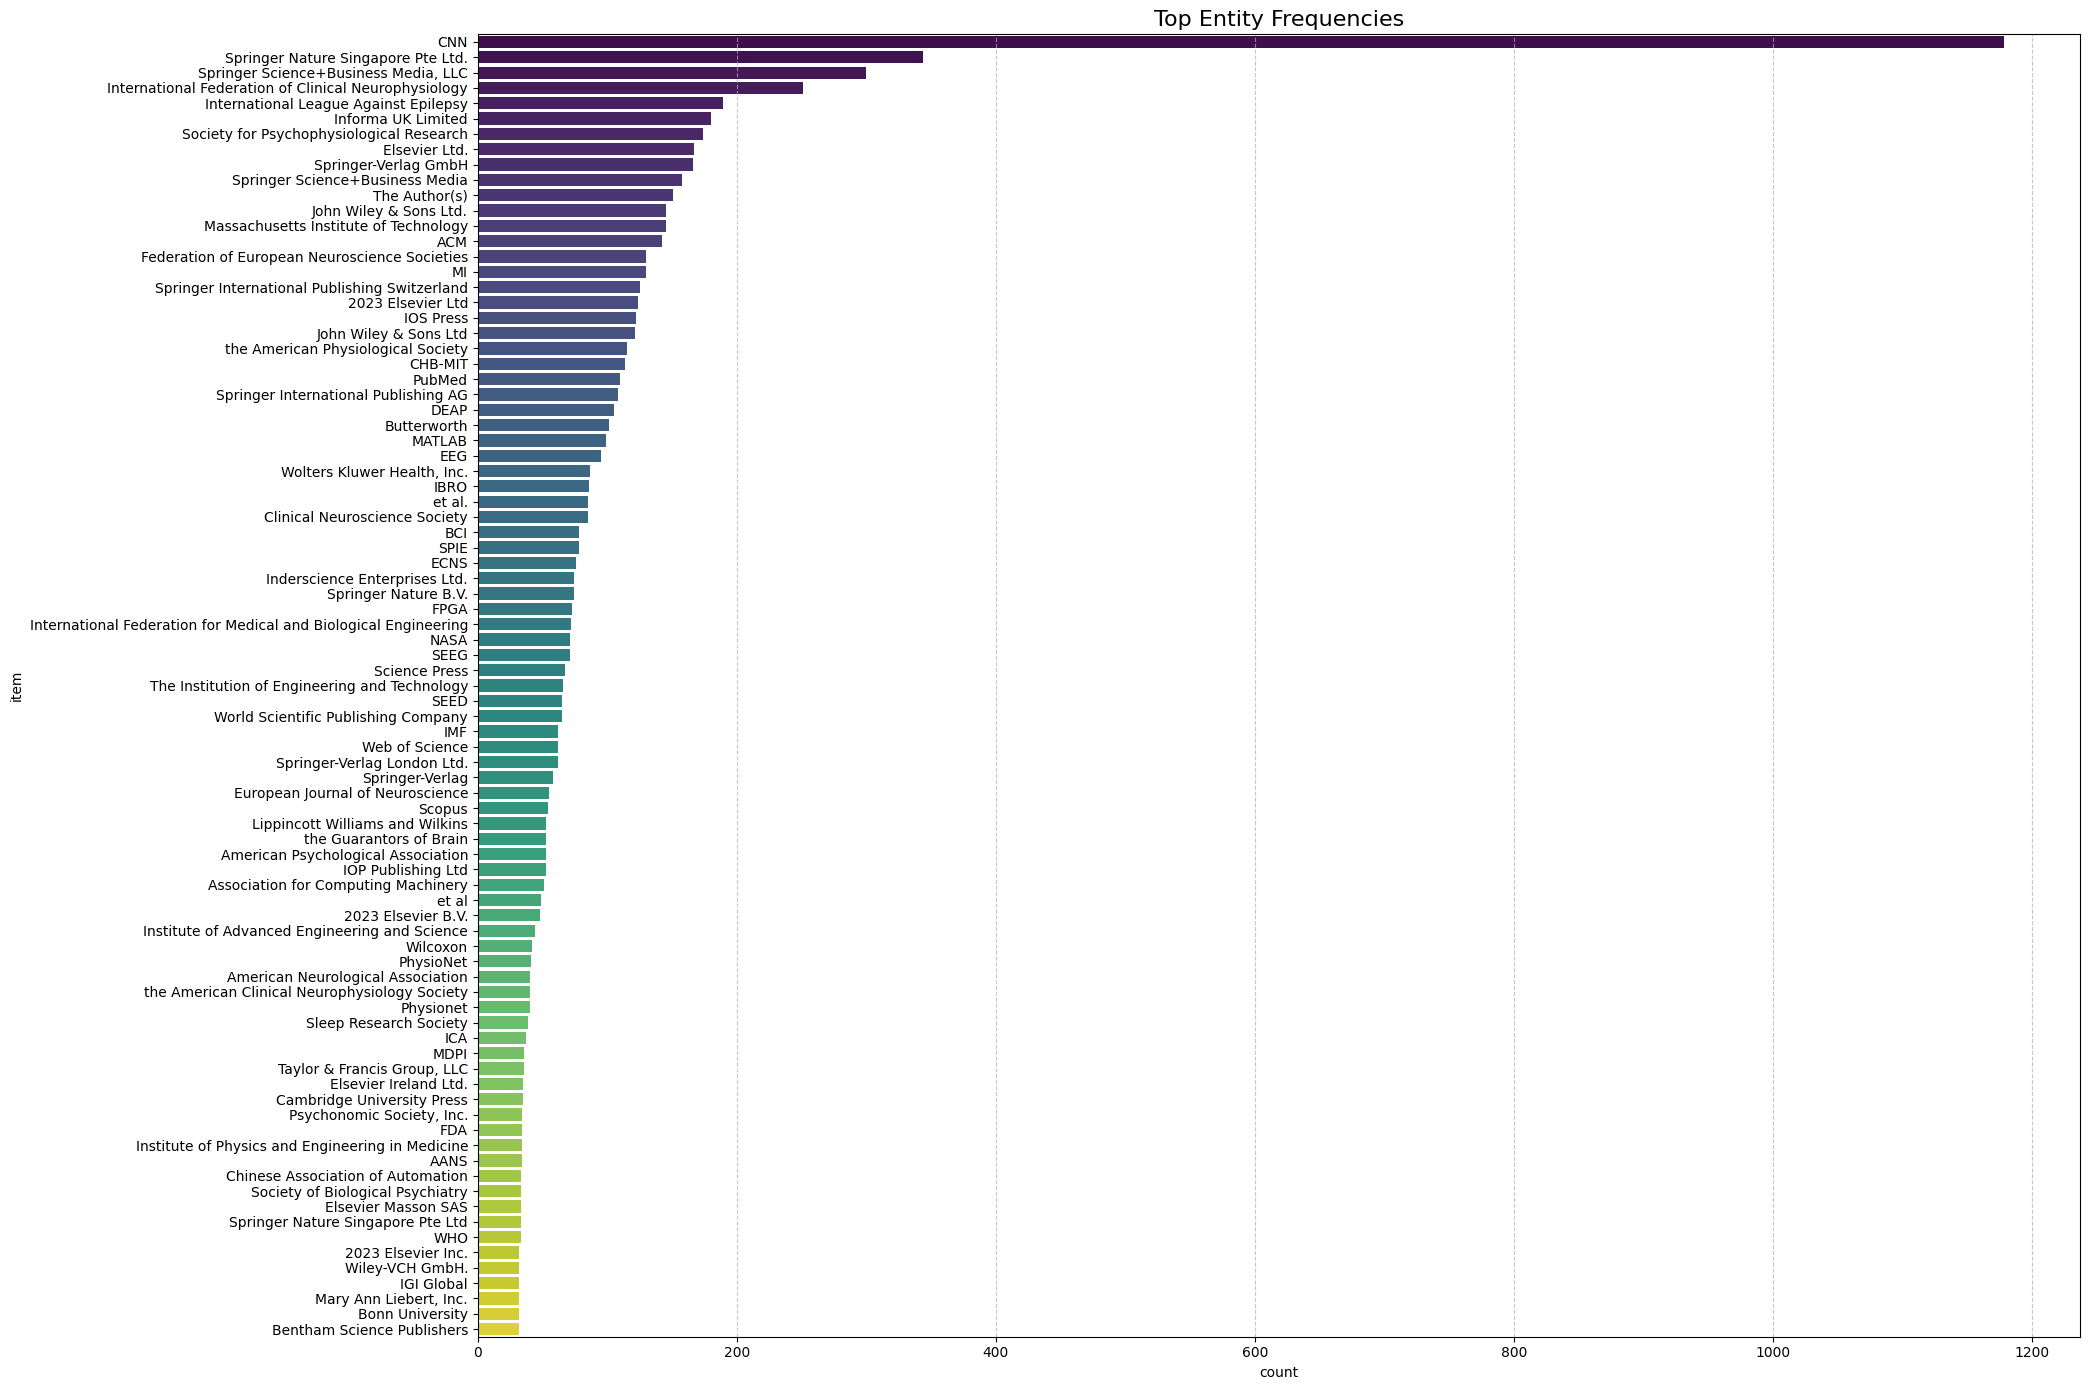

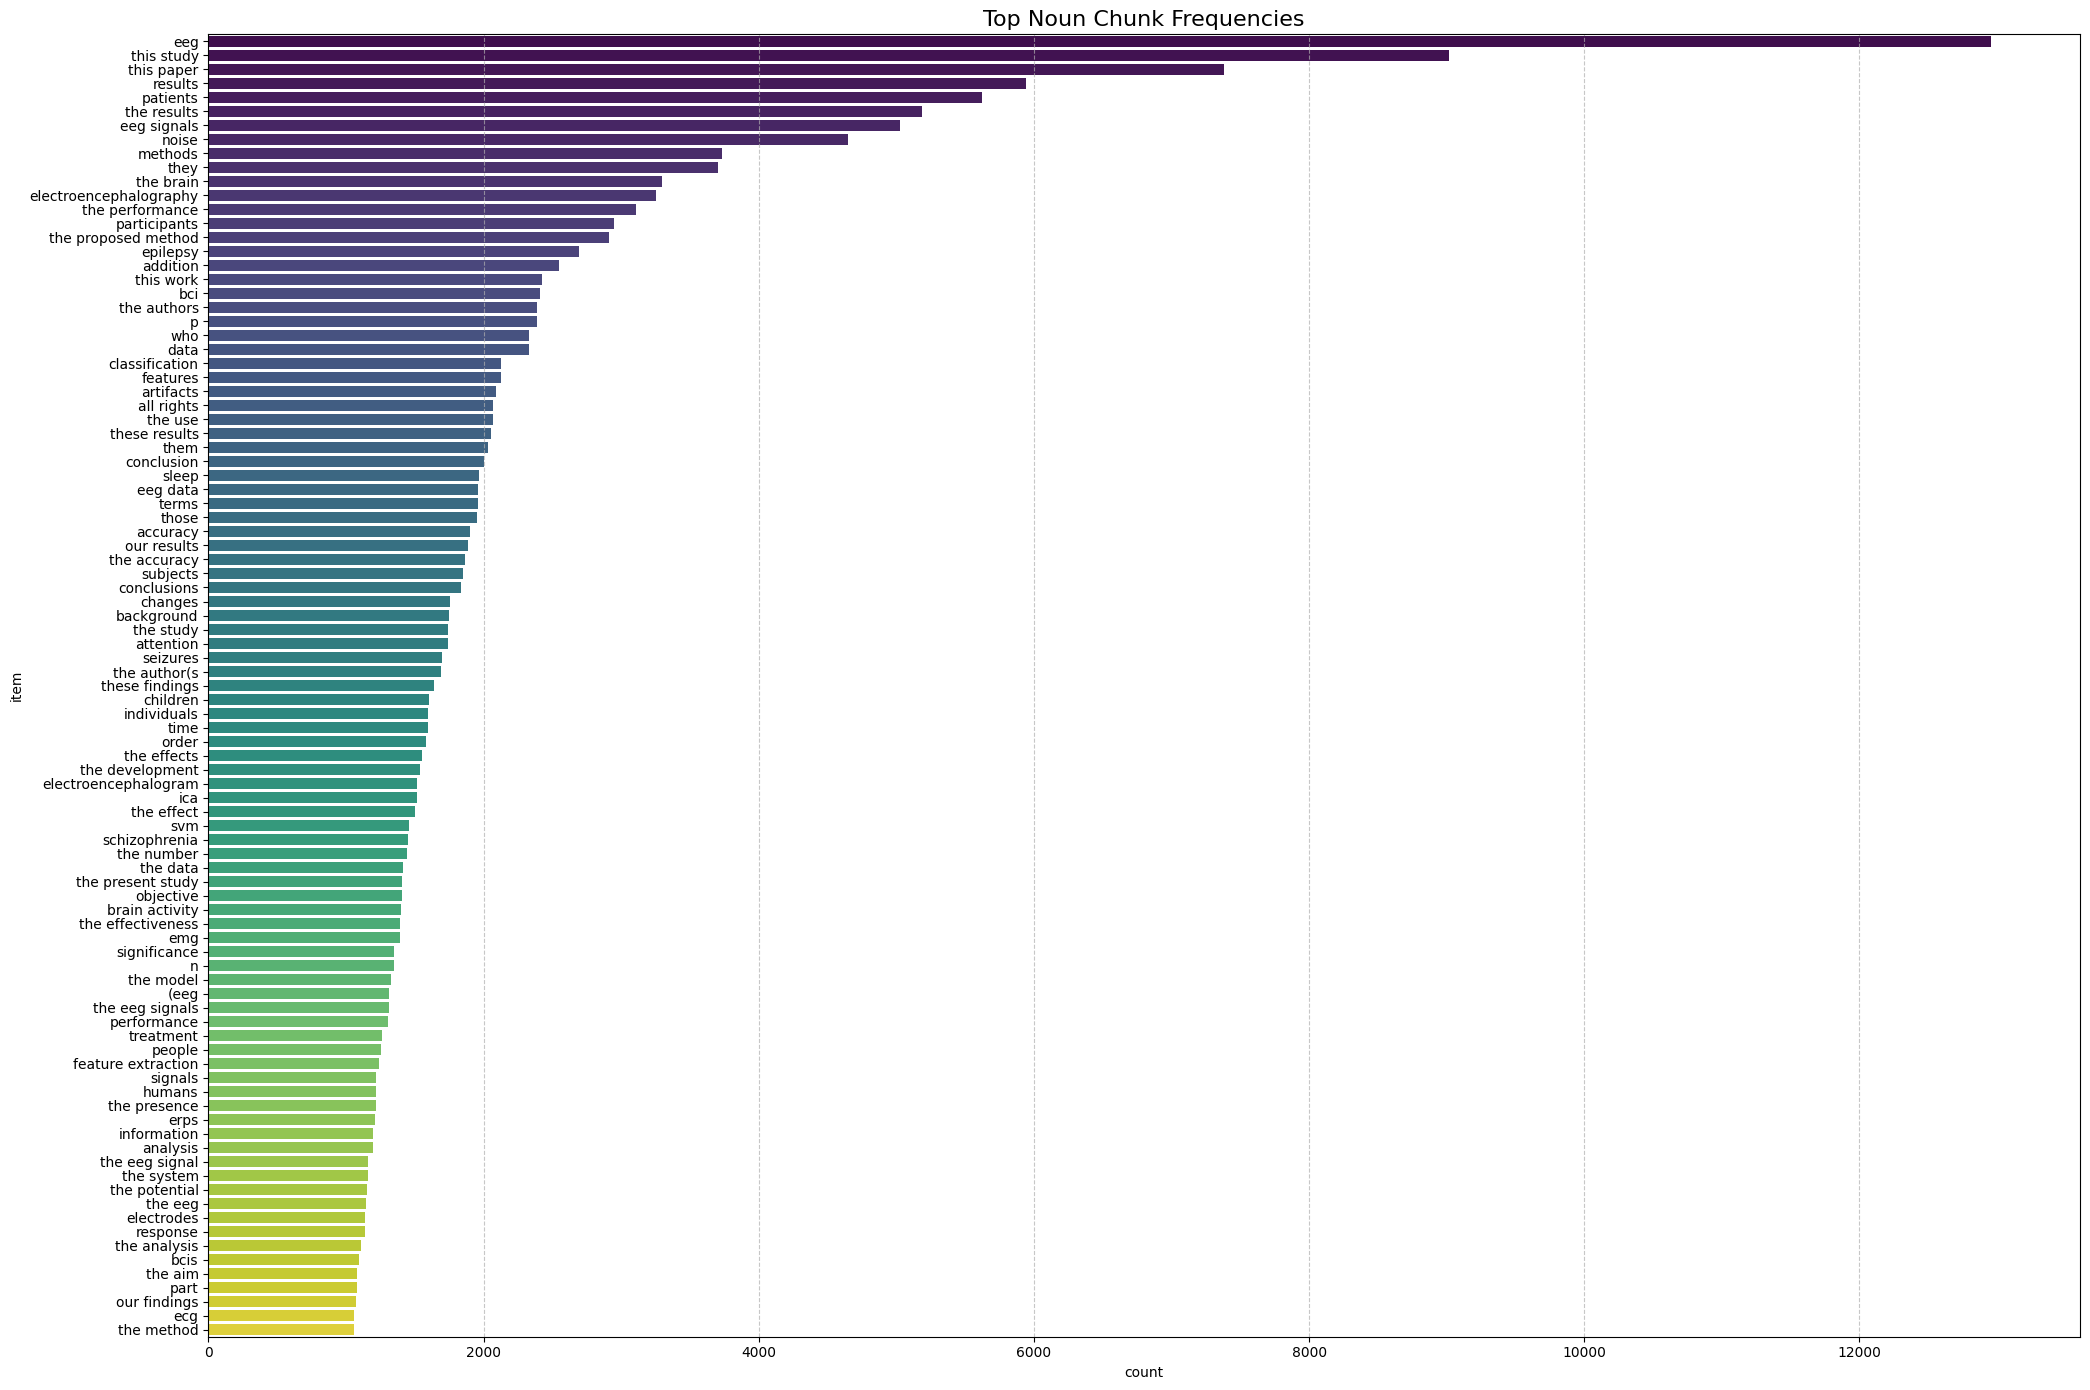

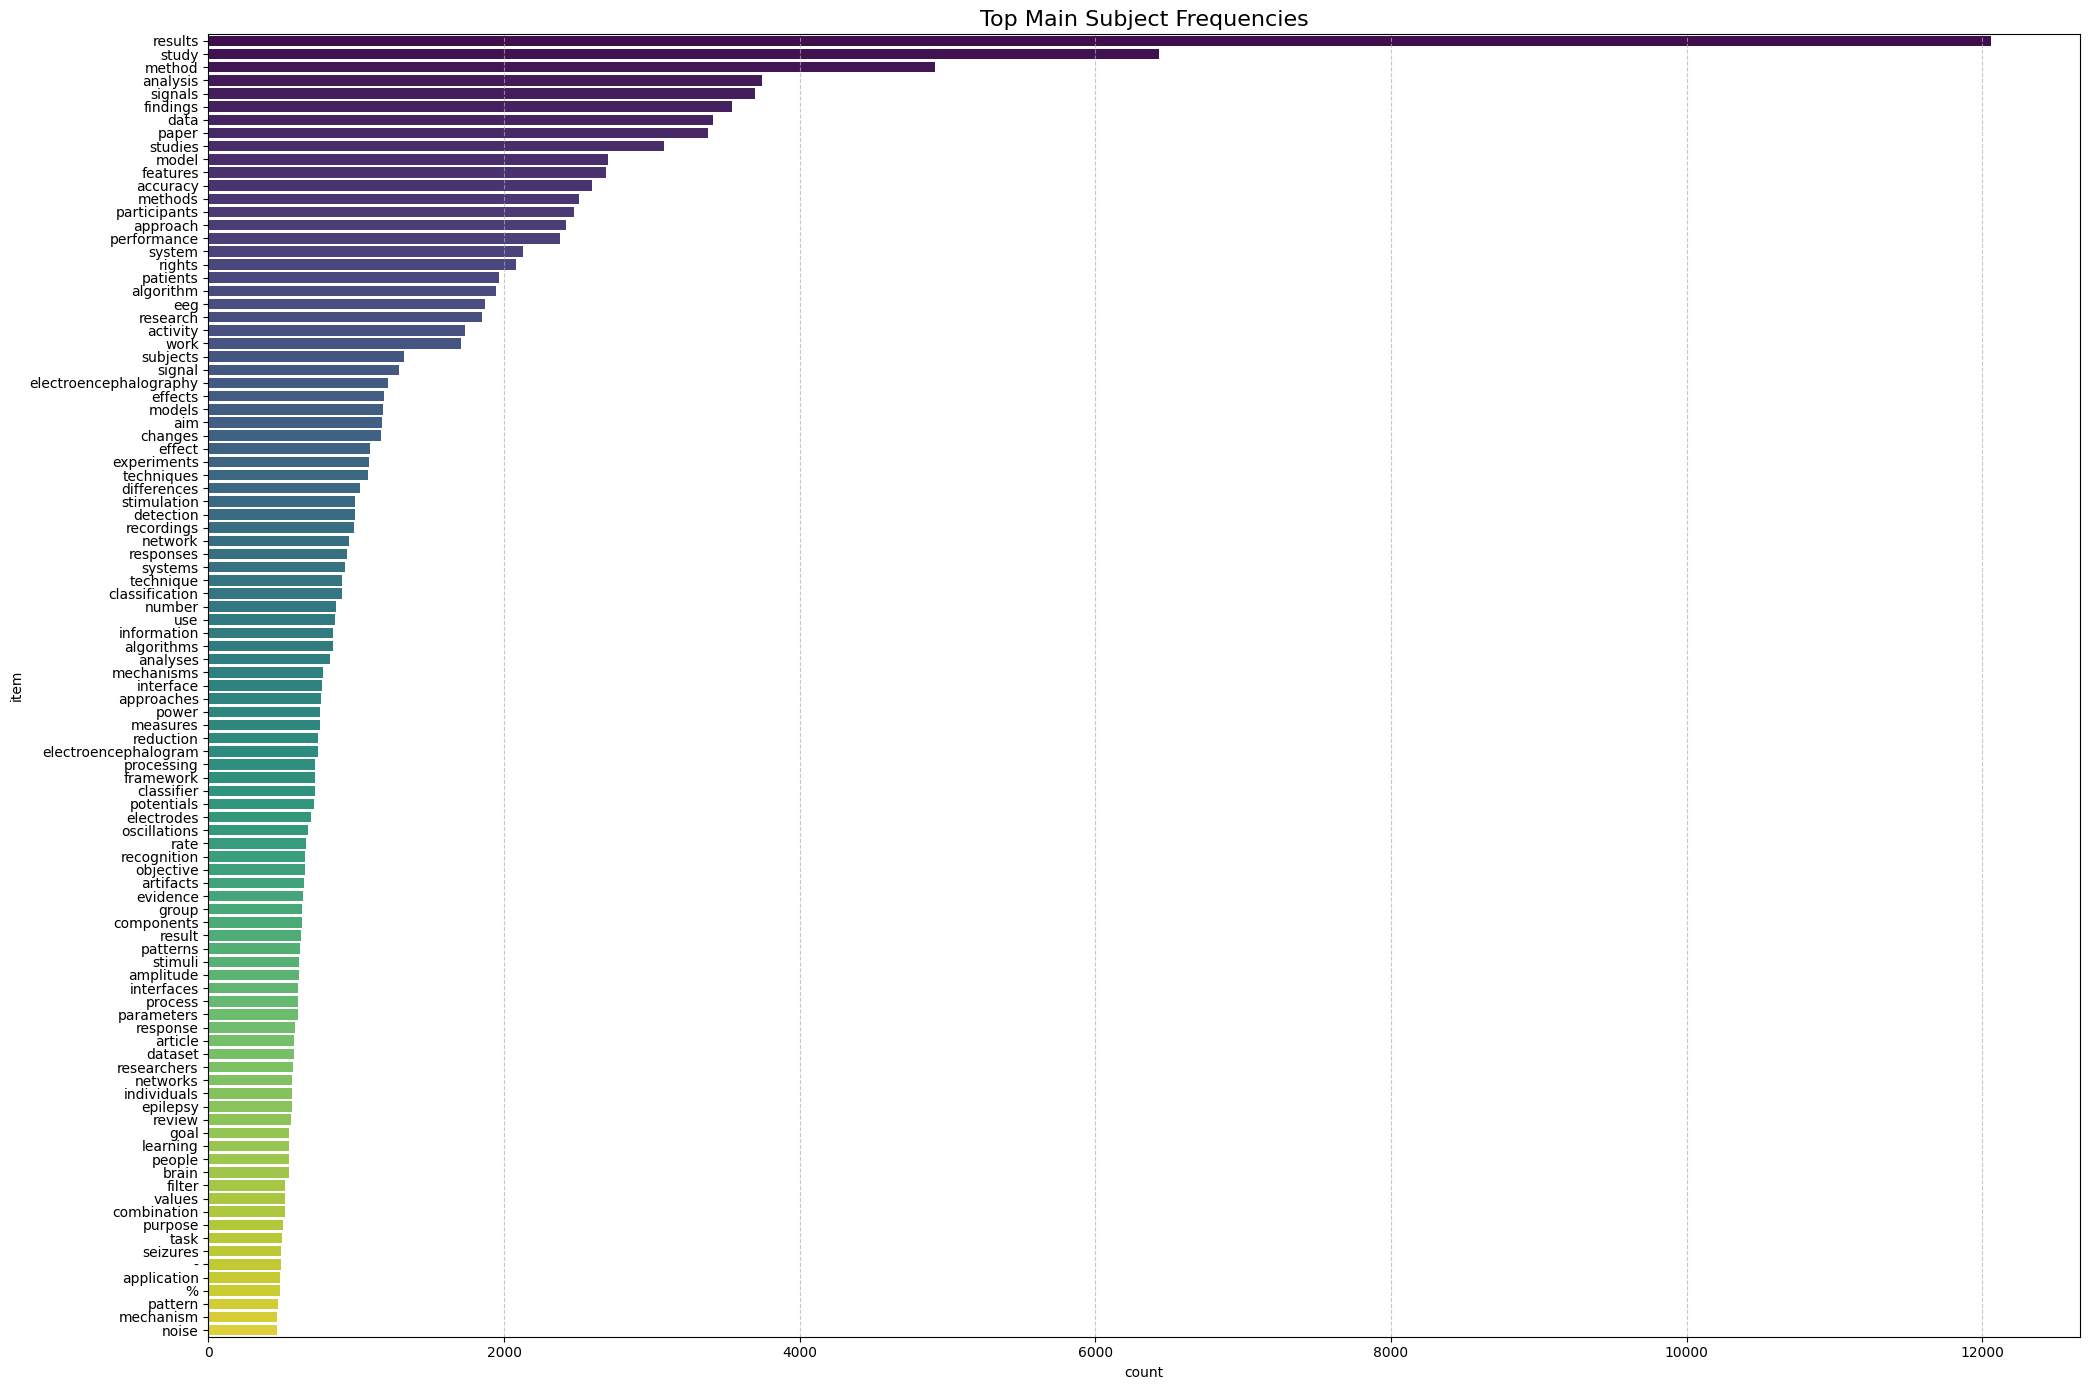

In [7]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming results_lm DataFrame is already defined and populated from your previous steps.
# If not, let's create a dummy one for demonstration:
try:
    results_lm # Check if it exists from previous execution
except NameError:
    data = {
        'meaningful_tokens': [['eeg', 'signal', 'brain'], ['method', 'study', 'eeg']],
        'entities': [['IEEE', 'Elsevier'], ['CNN', 'Elsevier', 'null']],
        'noun_chunks': [['we', 'this study'], ['eeg signals', 'the brain']],
        'main_subjects_unique': [['results', 'study'], ['method', 'analysis']]
    }
    results_lm = pl.DataFrame(data)


def count_list_column_items(df: pl.DataFrame, column_name: str) -> pl.DataFrame:
    """
    Counts the occurrences of each item within a list column across all rows.
    Returns a DataFrame with 'item' and 'count' columns.
    """
    return (
        df.lazy()
        .select(
            pl.col(column_name).explode().alias("item") # Explode flattens the lists into individual rows
        )
        .group_by("item")
        .len() # Count occurrences, Polars renames this to 'len' by default
        .sort("len", descending=True)
        .collect()
        .rename({"len": "count"}) # Rename 'len' to 'count' for clarity in plot
    )
l_number=100
# Get your frequency DataFrames
meaningful_token_counts = count_list_column_items(results_lm, "meaningful_tokens")
entity_counts = count_list_column_items(results_lm, "entities")
noun_chunk_counts = count_list_column_items(results_lm, "noun_chunks")
main_subject_counts = count_list_column_items(results_lm, "main_subjects_unique")


# --- Plotting Function ---
def plot_frequencies(df: pl.DataFrame, title: str, x_label: str, y_label: str = "Count", top_n: int = 50, exclude_items: list = None):
    """
    Generates a horizontal bar plot for frequency counts.
    """
    if df.is_empty():
        print(f"No data to plot for {title}")
        return

    # Convert to Pandas for easier plotting with Seaborn/Matplotlib
    # Polars to_pandas() is efficient.
    plot_df = df.head(top_n).to_pandas()

    if exclude_items:
        plot_df = plot_df[~plot_df['item'].isin(exclude_items)]
        if plot_df.empty:
            print(f"No data to plot for {title} after excluding items.")
            return

    plt.figure(figsize=(21, 14)) # Adjust figure size as needed for TikTok
    sns.barplot(x="count", y="item", data=plot_df,hue="item", palette="viridis", legend=False)
    plt.title(title, fontsize=16)
    #plt.xlabel(y_label, fontsize=12) # Swapped for horizontal bar
    #plt.ylabel(x_label, fontsize=12) # Swapped for horizontal bar
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid on x-axis for readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.savefig(x_label+".pdf")
    plt.show()


# --- Generate Plots ---

# Meaningful Tokens
plot_frequencies(
    meaningful_token_counts,
    "Top Meaningful Token Frequencies",
    "Meaningful Token",
    top_n=l_number, # Adjust top_n for readability on TikTok
    exclude_items=['©', 'ltd'] # Example of excluding noisy tokens
)

# Entities
# Explicitly exclude 'null' and potentially other publisher-related entities if they are noise
plot_frequencies(
    entity_counts,
    "Top Entity Frequencies",
    "Entity",
    top_n=l_number,
    exclude_items=['null', 'Elsevier B.V.', 'Elsevier Ltd', 'Elsevier Inc.', 'IOP Publishing Ltd.',
                   'Springer Nature Switzerland AG', 'Springer Nature', '2023 IEEE',
                   'The Authors', 'Licensee MDPI', 'Springer Nature Singapore Pte …',
                   'Wiley Periodicals LLC', 'Springer Science+Business Medi…',
                   'Oxford University Press', 'Wiley Periodicals, Inc.',
                   'Taylor & Francis Group', 'International Federation of Cl…',
                   'International League Against E…','IEEE'] # Add more as needed
)

# Noun Chunks
plot_frequencies(
    noun_chunk_counts,
    "Top Noun Chunk Frequencies",
    "Noun Chunk",
    top_n=l_number,
    exclude_items=['we', 'that', 'which', 'it', 'this', '©', '-'] # Exclude pronouns and noise
)

# Main Subjects Unique
plot_frequencies(
    main_subject_counts,
    "Top Main Subject Frequencies",
    "Main Subject",
    top_n=l_number
)

In [ ]:
import pyarrow.parquet as pq
pq.write_table(results_lm.to_arrow(), "abstract_tokens.parquet")


In [1]:
import polars as pl
import pandas as pd # For conversion to pandas for scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF # Or LatentDirichletAllocation for LDA
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import polars as pl
import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfTransformer

# Configuration
TERM_COL = "noun_chunks"
MIN_DOC_FREQ = 5  # Minimum documents a term must appear in
LEVEL1_TOPICS = 20
RANDOM_STATE = 42

# Load and preprocess data
results_lm = pl.read_parquet("abstract_tokens.parquet")

# Explode terms and clean
docs = (
    results_lm.lazy()
    .with_row_count("doc_id")
    .explode(TERM_COL)
    .filter(pl.col(TERM_COL).is_not_null() & (pl.col(TERM_COL) != "null"))
    .select(["doc_id", pl.col(TERM_COL).alias("term")])
    .collect()
)

# Document frequency filtering
term_doc_freq = (
    docs.select(["term", "doc_id"])
    .unique()
    .group_by("term")
    .agg(pl.count().alias("doc_freq"))
    .filter(pl.col("doc_freq") >= MIN_DOC_FREQ)
)

# Filter and index terms
filtered_terms = (
    docs.join(term_doc_freq, on="term", how="inner")
    .select("term")
    .unique()
    .with_row_index("term_id")
)

# Create document-term matrix
docs_mapped = (
    docs.join(filtered_terms, on="term", how="inner")
    .join(
        docs.select("doc_id").unique().with_row_index("doc_idx"),
        on="doc_id",
        how="left"
    )
)
try:
    rows = docs_mapped["doc_idx"].to_numpy().astype(np.int32)
    cols = docs_mapped["term_id"].to_numpy().astype(np.int32)
    data = np.ones(len(rows), dtype=np.float32)
    
    # Verify dimensions
    n_docs = docs_mapped["doc_idx"].max() + 1
    n_terms = len(filtered_terms)
    
    X = sp.coo_matrix(
        (data, (rows, cols)),
        shape=(n_docs, n_terms)
    ).tocsr()
    
    print(f"Built matrix with {X.shape[0]} docs and {X.shape[1]} terms")
    
except Exception as e:
    print(f"Error building matrix: {str(e)}")
    print("Debug info:")
    print(f"Rows dtype: {rows.dtype}, shape: {rows.shape}")
    print(f"Cols dtype: {cols.dtype}, shape: {cols.shape}")
    print(f"Data dtype: {data.dtype}, shape: {data.shape}")
    print(f"Target shape: ({n_docs}, {n_terms})")
    raise
    
# TF-IDF transformation
tfidf = TfidfTransformer().fit_transform(X)

# Level 1 Topics
lda_level1 = LatentDirichletAllocation(
    n_components=LEVEL1_TOPICS,
    random_state=RANDOM_STATE
)
term_topic_level1 = lda_level1.fit_transform(tfidf.T)
level1_pred = term_topic_level1.argmax(axis=1)

# Level 2 Subtopics
level2_pred = np.zeros(len(filtered_terms), dtype=int)
level2_ldas = {}

for topic_id in range(LEVEL1_TOPICS):
    mask = (level1_pred == topic_id)
    n_terms = mask.sum()
    
    if n_terms < 10:
        continue
        
    n_subtopics = min(5, max(3, n_terms // 20))
    lda_subtopic = LatentDirichletAllocation(
        n_components=n_subtopics,
        random_state=RANDOM_STATE
    )
    level2_pred[mask] = (
        lda_subtopic.fit_transform(tfidf.T[mask]).argmax(axis=1) 
        + (topic_id * 10)  # Unique subtopic IDs
    )
    level2_ldas[topic_id] = lda_subtopic

# Manual topic names
manual_topic_names = {
    0: "Noise Filtering Basics",          # Rare but appears in Adaptive Filtering
    1: "EEG Artifact Removal",            # Strong in EOG/EMG, BCI, and Clinical
    2: "Wavelet & Time-Frequency Methods", # Dominates Wavelet Denoising, ICA
    3: "Rare/Uncommon Methods",           # Low-frequency across concepts
    4: "Hardware/Instrumentation",        # Appears in Adaptive Filtering, Sleep
    5: "Classical Signal Processing",     # Moderate in EMG, Preprocessing
    6: "Clinical EEG Analysis",           # Dominates Seizures, Sleep
    7: "Neuroscience Applications",       # Strong in Sleep, Deep Learning
    8: "Machine Learning Foundations",    # High in Deep Learning, BCI
    9: "Powerline Noise Mitigation",      # Specific to Powerline Noise
    10: "Advanced BCI Techniques",        # Appears in BCI, Deep Learning
    11: "Niche Biomedical Applications",  # Low but consistent presence
    12: "General EEG Processing",         # Dominates ALL concepts (likely catch-all)
    13: "Source Reconstruction",          # Strong in ICA, Source Localization
    14: "Experimental Paradigms",         # Minor in Sleep/Clinical
    15: "Real-time Systems",              # Appears in BCI, EMG
    16: "Epilepsy Detection",             # Dominates Clinical Seizures
    17: "Multimodal Signal Analysis",     # Top 2 in Wavelet/ICA/Deep Learning
    18: "Theoretical Methods",            # Rare (seen in ICA)
    19: "EMG-Specific Processing"         # Strong in EMG Artifacts
}

# Final taxonomy
taxonomy = pl.DataFrame({
    "term": filtered_terms["term"],
    "level1_pred": level1_pred,
    "level1_topic_name": [manual_topic_names[t] for t in level1_pred],
    "level2_pred": level2_pred,
    "level2_parent": (level2_pred // 10),
    "level2_local": (level2_pred % 10)
})

# Analysis of results
print("\n=== Term Distribution ===")
print(f"Original terms: {len(docs.select('term').unique())}")
print(f"Filtered terms: {len(filtered_terms)}")
print(f"Filtering ratio: {len(filtered_terms)/len(docs.select('term').unique()):.1%}")

print("\n=== Topic Coverage ===")
topic_counts = (
    taxonomy.group_by("level1_pred", "level1_topic_name")
    .agg(pl.count().alias("term_count"))
    .sort("term_count", descending=True)
)
print(topic_counts)

/tmp/ipykernel_217/22972419.py:19: DeprecationWarning: `LazyFrame.with_row_count` is deprecated; use `LazyFrame.with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count("doc_id")
/tmp/ipykernel_217/22972419.py:31: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("doc_freq"))


Built matrix with 33000 docs and 32884 terms
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/joaot/myenv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3670, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_217/22972419.py", line 85, in <module>
    term_topic_level1 = lda_level1.fit_transform(tfidf.T)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/joaot/myenv/lib/python3.11/site-packages/sklearn/utils/_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/joaot/myenv/lib/python3.11/site-packages/sklearn/decomposition/_lda.py", line 778, in fit_transform
    return self.fit(X, y).transform(X, normalize=normalize)
           ^^^^^^^^^^^^^^
  File "/home/joaot/myenv/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/joaot/myen

In [79]:
taxonomy.write_parquet("lv_2_taxonomy.parquet")

In [ ]:
taxonomy.filter(pl.col("level1_pred")==0)

In [33]:
taxonomy=pl.read_parquet("lv_2_taxonomy.parquet")
counter=0
x=0
y=1
for i in taxonomy.filter(pl.col("level1_pred")==x).filter(pl.col("level2_local")==y)["term"]:
    counter+=1
    if counter==50:
        break
    print(i)

non-invasive electroencephalography
time interval
their detection
advanced science
our features
an alternative means
erp detection
the preprocessing pipeline
specific brain activities
0.2 hz
welch
these stages
comparison experiments
target items
the characteristic frequency
active participation
average area
a comprehensive investigation
the eye tracker
subbands
biometric systems
everyday environments
recent literature
the main purpose
single-trial classification
the exclusion
user authentication
the rank
sonification
the generalization capability
lda classifiers
upper limb
the effective number
clear speech
the discrimination power
sixteen participants
focused ultrasound
the quest
k nearest neighbors
hou
a limited range
data representation
a feature set
most participants
the walking speed
statistical differences
a higher classification accuracy
mit
the sake


In [82]:
taxonomy.sort("level1_pred", descending=True)

search_patterns = {
    "ICA": r"(?i)independent component analysis|blind source separation",
    "Wavelet Denoising": r"(?i)wavelet|denoising method|multiresolution analysis",
    "Adaptive Filtering": r"(?i)adaptive filter|least mean square|lms",
    "Deep Learning": r"(?i)deep learning|cnn|rnn|neural network|autoencoder",
    "EOG Artifacts": r"(?i)eog|electrooculogram|eye blink|eye movement",
    "EMG Artifacts": r"(?i)emg|electromyogram|muscle artifact",
    "Powerline Noise": r"(?i)powerline|line noise|60 hz|50 hz",
    "Preprocessing": r"(?i)preprocessing|data cleaning|signal preparation",
    "Source Localization": r"(?i)source localization|inverse problem|brain source",
    "BCI": r"(?i)bci|brain computer interface|motor imagery",
    "Clinical Seizures": r"(?i)seizure|epilepsy|ictal|interictal",
    "Sleep Analysis": r"(?i)sleep|sleep stage|polysomnography",
    # Add more as per your "top 20 denoising techniques" or other expected themes
}

# Assuming taxonomy is your DataFrame
# Example: Find terms containing "wavelet" as a literal string
wavelet_terms_exact = taxonomy.filter(
    pl.col("term").str.contains("(?i)wavelet", literal=False) # literal=False is default for regex, but (?i) makes it case-insensitive
)
print("\n--- Terms containing 'wavelet' (literal substring, case-insensitive) ---")
print(wavelet_terms_exact.group_by(pl.col("level1_pred")).len().sort("len",descending=True))


# Corrected loop to iterate over concept (key) and pattern (value)
for concept, pattern in search_patterns.items():
    print(f"\n--- Results for Concept: '{concept}' (Pattern: '{pattern}') ---")

    a=taxonomy.filter(
    pl.col("term").str.contains(pattern, literal=False) # literal=False is default for regex, but (?i) makes it case-insensitive
)
    with pl.Config(tbl_rows=20):
    # Print the head of the filtered DataFrame, as you requested
        print(a.group_by(pl.col("level1_pred")).len().sort("len",descending=True))


--- Terms containing 'wavelet' (literal substring, case-insensitive) ---
shape: (9, 2)
┌─────────────┬─────┐
│ level1_pred ┆ len │
│ ---         ┆ --- │
│ i64         ┆ u32 │
╞═════════════╪═════╡
│ 1           ┆ 25  │
│ 13          ┆ 21  │
│ 0           ┆ 13  │
│ 8           ┆ 3   │
│ 19          ┆ 3   │
│ 15          ┆ 2   │
│ 6           ┆ 1   │
│ 11          ┆ 1   │
│ 5           ┆ 1   │
└─────────────┴─────┘

--- Results for Concept: 'ICA' (Pattern: '(?i)independent component analysis|blind source separation') ---
shape: (7, 2)
┌─────────────┬─────┐
│ level1_pred ┆ len │
│ ---         ┆ --- │
│ i64         ┆ u32 │
╞═════════════╪═════╡
│ 0           ┆ 5   │
│ 8           ┆ 3   │
│ 13          ┆ 2   │
│ 19          ┆ 1   │
│ 11          ┆ 1   │
│ 18          ┆ 1   │
│ 9           ┆ 1   │
└─────────────┴─────┘

--- Results for Concept: 'Wavelet Denoising' (Pattern: '(?i)wavelet|denoising method|multiresolution analysis') ---
shape: (9, 2)
┌─────────────┬─────┐
│ level1_pred ┆ len │

In [86]:
# Revised naming approach that will work correctly
revised_topic_names = {
    0: "General Signal Processing",
    1: "EEG Artifact Removal",
    2: "Time-Frequency Methods",
    3: "Uncommon Methods",
    4: "Hardware/Instrumentation",
    5: "Classical Signal Processing",
    6: "Clinical EEG Features",
    7: "Cognitive Neuroscience",
    8: "Machine Learning Methods",
    9: "Powerline Noise",
    10: "Advanced BCI Paradigms",
    11: "Biomedical Special Cases",
    12: "Fundamental EEG Processing",
    13: "Source Analysis",
    14: "Sleep/State Analysis",
    15: "Clinical Event Detection",
    16: "Epilepsy Detection",
    17: "Multimodal Integration",
    18: "Theoretical Models",
    19: "EMG/Peripheral Processing"
}

taxonomy = taxonomy.with_columns(
    pl.col("level1_pred").replace_strict(revised_topic_names,default="unknown").alias("revised_topic_name")
)

# More maintainable alternative using a mapping function
def get_topic_name(topic_id: int) -> str:
    return revised_topic_names.get(topic_id, "Unknown")

taxonomy = taxonomy.with_columns(
    pl.col("level1_pred").map_elements(get_topic_name).alias("revised_topic_name")
)

/tmp/ipykernel_1597/1266186521.py:33: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  taxonomy = taxonomy.with_columns(


In [29]:
topic_to_search_patterns = {
    # Topic 0: General Signal Processing
    0: {
        "Fourier Transform and Spectral Analysis": r"(?i)fft|spectral|fourier|transform",
        "Digital Filter Design (FIR, IIR)": r"(?i)digital filter|fir|iir|finite impulse|infinite impulse",
        "Signal-to-Noise Ratio (SNR) Enhancement": r"(?i)snr|signal.?to.?noise|noise reduction|denois",
        "Nyquist Theorem and Sampling Rates": r"(?i)nyquist|sampling rate|aliasing|shannon",
        "Non-Stationary Signal Analysis": r"(?i)non.?stationary|time.?varying|transient signal"
    },
    # Topic 1: EEG Artifact Removal
    1: {
        "Independent Component Analysis (ICA) for EEG": r"(?i)ica|independent component|blind source",
        "Regression-Based Artifact Correction": r"(?i)regression.?based|artifact correction|eog removal",
        "Ocular Artifact Removal (EOG)": r"(?i)eog|ocular|eye blink|eye movement",
        "Muscle Artifact Handling (EMG)": r"(?i)emg|muscle artifact|myogenic",
        "Adaptive Filtering for Motion Artifacts": r"(?i)adaptive filter|motion artifact|lms|rls"
    },
    # Topic 2: Time-Frequency Methods
    2: {
        "Wavelet Transform for EEG": r"(?i)wavelet|daubechies|morlet|multiresolution",
        "Short-Time Fourier Transform (STFT)": r"(?i)stft|short.?time fourier|spectrogram",
        "Hilbert-Huang Transform (HHT)": r"(?i)hilbert.?huang|hht|empirical mode",
        "Spectrograms and Power Spectral Density": r"(?i)spectrogram|power spectral|psd",
        "Time-Frequency Resolution Trade-offs": r"(?i)time.?frequency|heisenberg|uncertainty principle"
    },
    # Topic 3: Uncommon Methods
    3: {
        "Sparse Signal Processing in EEG": r"(?i)sparse signal|compressed sensing|l1 norm",
        "Nonlinear Dynamics (Chaos Theory)": r"(?i)nonlinear|chaos theory|lyapunov",
        "Topological Data Analysis (TDA)": r"(?i)topological data|persistence|morse",
        "Riemannian Geometry for EEG": r"(?i)riemannian|manifold|covariance matrix",
        "Quantum Signal Processing Concepts": r"(?i)quantum signal|qubit|quantum fourier"
    },
    # Topic 4: Hardware/Instrumentation
    4: {
        "EEG Amplifiers and ADC Selection": r"(?i)eeg amplifier|adc|analog.?digital",
        "Electrode Types (Wet, Dry, Active)": r"(?i)electrode|wet electrode|dry electrode|active electrode",
        "Noise Shielding and Grounding": r"(?i)shielding|grounding|faraday",
        "Wireless EEG Systems": r"(?i)wireless eeg|bci headset|mobile eeg",
        "Impedance Measurement and Reduction": r"(?i)impedance|contact quality|skin preparation"
    }
    # Continue for remaining topics...
}

In [30]:
topic_to_search_patterns[0]

{'Fourier Transform and Spectral Analysis': '(?i)fft|spectral|fourier|transform',
 'Digital Filter Design (FIR, IIR)': '(?i)digital filter|fir|iir|finite impulse|infinite impulse',
 'Signal-to-Noise Ratio (SNR) Enhancement': '(?i)snr|signal.?to.?noise|noise reduction|denois',
 'Nyquist Theorem and Sampling Rates': '(?i)nyquist|sampling rate|aliasing|shannon',
 'Non-Stationary Signal Analysis': '(?i)non.?stationary|time.?varying|transient signal'}

In [31]:
taxonomy.sort("level1_pred", descending=True)

search_patterns = {
    "ICA": r"(?i)independent component analysis|blind source separation",
    "Wavelet Denoising": r"(?i)wavelet|denoising method|multiresolution analysis",
    "Adaptive Filtering": r"(?i)adaptive filter|least mean square|lms",
    "Deep Learning": r"(?i)deep learning|cnn|rnn|neural network|autoencoder",
    "EOG Artifacts": r"(?i)eog|electrooculogram|eye blink|eye movement",
    "EMG Artifacts": r"(?i)emg|electromyogram|muscle artifact",
    "Powerline Noise": r"(?i)powerline|line noise|60 hz|50 hz",
    "Preprocessing": r"(?i)preprocessing|data cleaning|signal preparation",
    "Source Localization": r"(?i)source localization|inverse problem|brain source",
    "BCI": r"(?i)bci|brain computer interface|motor imagery",
    "Clinical Seizures": r"(?i)seizure|epilepsy|ictal|interictal",
    "Sleep Analysis": r"(?i)sleep|sleep stage|polysomnography",
    # Add more as per your "top 20 denoising techniques" or other expected themes
}

key=0
first=taxonomy.filter(pl.col("level1_pred")==key)

# Then analyze search patterns
for concept, pattern in topic_to_search_patterns[key].items():
    print(f"\n--- Concept: '{concept}' (Pattern: '{pattern}') ---")
    
    # Filter terms matching the pattern within our pre-filtered data
    matches = first.filter(
        pl.col("term").str.contains(pattern)
    )
    
    # Count matches per category (though we've already filtered to specific x/y)
    counts = matches.group_by("level2_local").len().sort("len", descending=True)
    
    with pl.Config(tbl_rows=20):
        print(counts)
        print("Matching terms:", matches["term"].to_list())


--- Concept: 'Fourier Transform and Spectral Analysis' (Pattern: '(?i)fft|spectral|fourier|transform') ---
shape: (4, 2)
┌──────────────┬─────┐
│ level2_local ┆ len │
│ ---          ┆ --- │
│ i64          ┆ u32 │
╞══════════════╪═════╡
│ 0            ┆ 13  │
│ 2            ┆ 4   │
│ 3            ┆ 2   │
│ 1            ┆ 2   │
└──────────────┴─────┘
Matching terms: ['the hilbert transform', 'spatio-spectral decomposition', 'the spectral properties', 'the spectral characteristics', 'the transformation', 'the power spectral density', 'power spectral density analysis', 'empirical wavelet transform', 'the fourier transform', 'continuous wavelet transformation', 'fast fourier transforms', 'fast fourier transformation', 'the transformer', 'power spectral density', 'daubechies wavelet transform', 'stockwell transform', 'the spectral domain', 'a continuous wavelet transform', 'the hilbert-huang transform', 'transformation', 'morlet wavelet transform']

--- Concept: 'Digital Filter Design (FIR,

In [38]:
pl_df

Title,Abstract,Authors,Affiliations,Year,Source,Author Keywords,Cite Count,DOI
str,str,str,str,i64,str,str,f64,str
"""Deep manifold learning for the…","""Intracranial neural activity r…","""Wu, Lingyun (57226766385); Hu,…","""Department of Neurology, Tangs…",2025,"""Biomed. Signal Process. Contro…","""Deep manifold learning; EEG; I…",0.0,"""10.1016/j.bspc.2024.107335"""
"""Enhancing motor imagery task r…","""Motor imagery electroencephalo…","""Dovedi, Tanvi (57215744556); U…","""Department of Electronics and …",2025,"""Biomed. Signal Process. Contro…","""Brain-Computer Interface; Clas…",0.0,"""10.1016/j.bspc.2024.107149"""
"""MCMTNet: Advanced network arch…","""Brain–computer interface (BCI)…","""Yang, Yingjie (59493581600); Z…","""Tianjin Key Laboratory of Wire…",2025,"""Neurocomputing""","""Brain–machine interface; Convo…",0.0,"""10.1016/j.neucom.2024.129255"""
"""Technical validation of the Ze…","""Objective. Clinical adoption o…","""Nadasdy, Zoltan (6603325593); …","""Zeto, Inc., Santa Clara, CA, U…",2025,"""Biomed. Phys. Eng. Express""","""dry electrodes; EEG; Hjorth pa…",0.0,"""10.1088/2057-1976/ada4b6"""
"""Learning-based EEG rhythm anal…","""One of the major challenges in…","""Wu, Xiaopei (7407061828); Ouya…","""School of Computer Science and…",2025,"""Biomed. Signal Process. Contro…","""Brain-computer interface; EEG …",0.0,"""10.1016/j.bspc.2024.107345"""
…,…,…,…,…,…,…,…,…
"""A Fully Integrated 8-Channel C…","""An 8-channel closed-loop neura…","""W. -M. Chen; H. Chiueh; T. -J.…","""Department of Electronics Engi…",2014,"""IEEE Journal of Solid-State Ci…","""Closed-loop control;epilepsy;n…",214.0,null
"""A Smart Textile Based Facial E…","""This paper investigates a wear…","""G. M. Paul; F. Cao; R. Torah; …","""Department of Electronics and …",2014,"""IEEE Sensors Journal""","""Biopotentials;EMG;EOG;screen p…",85.0,null
"""Minimum Variance Brain Source …","""In the electroencephalogram (E…","""M. Ravan; J. P. Reilly; G. Has…","""Cyberonics, Inc., Houston, TX,…",2014,"""IEEE Transactions on Biomedica…","""Beamforming;brain source local…",9.0,null


In [46]:
pl_df.filter(pl.col("Abstract").is_not_null()).select("Abstract").min()

Abstract
str
""" A…"


In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import polas as pl


documents_for_bertopic = pl_df.filter(pl.col("Abstract").is_not_null()).select("Abstract").to_series().to_list()
print(f"Prepared {len(documents_for_bertopic)} documents for BERTopic.")
# --- Advanced Configuration ---
# Custom embedding model (optional)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Custom vectorizer for better topic representation
vectorizer = CountVectorizer(stop_words="english", 
                           ngram_range=(1, 2), 
                           min_df=5, 
                           max_df=0.8)

# UMAP configuration
umap_model = UMAP(n_neighbors=15, 
                 n_components=5, 
                 metric='cosine', 
                 random_state=42,
                 low_memory=True)  # For large datasets

# HDBSCAN configuration
hdbscan_model = HDBSCAN(min_cluster_size=10,
                       metric='euclidean',
                       cluster_selection_method='eom',
                       prediction_data=True,
                       min_samples=5)  # Controls cluster density

# --- Initialize BERTopic ---
topic_model = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True,
    nr_topics="auto",
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=embedding_model,  # Optional custom embedding
    vectorizer_model=vectorizer,     # Better topic representation
)

# --- Fit and Transform ---
topics, probs = topic_model.fit_transform(documents_for_bertopic)

# --- Enhanced Results Extraction ---
# Get topic info with additional metrics
topics_info = topic_model.get_topic_info()
topics_info["Document_Count"] = topics_info["Count"]  # More descriptive column name
print("\n--- Enhanced Topic Information ---")
print(topics_info[['Topic', 'Name', 'Document_Count', 'Representation']].head(10))

# --- Hierarchical Topic Analysis ---
try:
    hierarchical_topics = topic_model.hierarchical_topics(documents_for_bertopic)
    tree = topic_model.get_topic_tree(hierarchical_topics)
    print("\n--- Hierarchical Topic Structure ---")
    print(tree)
    
    # Visualize hierarchy
    fig = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
    fig.show()
except Exception as e:
    print(f"\nHierarchy generation failed: {str(e)}")

# --- Advanced Visualizations ---
# Topic similarity matrix
similarity_matrix = topic_model.visualize_heatmap()
similarity_matrix.show()

# Intertopic distance map
distance_map = topic_model.visualize_topics()
distance_map.show()

# --- Topic Reduction (Optional) ---
if len(topics_info) > 50:  # Only reduce if many topics
    reduced_topics = topic_model.reduce_topics(documents_for_bertopic, 
                                             nr_topics=30)
    print("\nReduced from", len(topics_info), "to 30 topics")

# --- Topic Quality Analysis ---
topic_sizes = topics_info["Document_Count"].value_counts()
print("\nTopic Size Distribution:")
print(topic_sizes)

try:
    outlier_count = sum(1 for t in topics if t == -1)
    outlier_percentage = (outlier_count / len(topics)) * 100
    print(f"Outlier Percentage (alt method): {outlier_percentage:.2f}%")
except Exception as e:
    print(f"Could not calculate outliers: {str(e)}")

# --- Save/Load Model ---
topic_model.save("bertopic_model")  # Saves all components
# loaded_model = BERTopic.load("bertopic_model")

print("\nBERTopic analysis complete. Key outputs:")
print("- topics_info: DataFrame with topic metadata")
print("- topics: Array of document topic assignments")
print("- probs: Topic probability distributions")

In [59]:
import os
import pickle
import pandas as pd
from pathlib import Path

# Create output directory
output_dir = Path("bertopic_results")
output_dir.mkdir(exist_ok=True)

def save_bertopic_results(topic_model, topics, probs, documents):
    """Save all BERTopic results to files"""
    try:
        # 1. Save the full model
        with open(output_dir/"bertopic_model.pkl", "wb") as f:
            pickle.dump(topic_model, f)
        
        # 2. Save numerical results
        results = {
            "topics": topics,
            "probs": probs,
            "documents": documents
        }
        with open(output_dir/"numerical_results.pkl", "wb") as f:
            pickle.dump(results, f)
        
        # 3. Save topic info as CSV
        topics_info = topic_model.get_topic_info()
        topics_info.to_csv(output_dir/"topics_info.csv", index=False)
        
        # 4. Save visualizations in vector formats
        save_vector_visualizations(topic_model)
        
        print(f"Successfully saved all results to {output_dir}")
        return True
    except Exception as e:
        print(f"Error saving results: {str(e)}")
        return False

def save_vector_visualizations(topic_model):
    """Save plots in SVG/PDF formats"""
    try:
        # Hierarchy visualization
        fig = topic_model.visualize_hierarchy()
        fig.write_image(output_dir/"hierarchy.svg")
        fig.write_image(output_dir/"hierarchy.pdf")
        
        # Heatmap visualization
        fig = topic_model.visualize_heatmap()
        fig.write_image(output_dir/"heatmap.svg") 
        fig.write_image(output_dir/"heatmap.pdf")
        
        # Intertopic distance
        fig = topic_model.visualize_topics()
        fig.write_image(output_dir/"intertopic_distance.svg")
        fig.write_image(output_dir/"intertopic_distance.pdf")
        
        # Topic barcharts
        fig = topic_model.visualize_barchart(top_n_topics=10)
        fig.write_image(output_dir/"topic_barcharts.svg")
        fig.write_image(output_dir/"topic_barcharts.pdf")
    except Exception as e:
        print(f"Visualization save failed: {str(e)}")

# Execute saving
save_success = save_bertopic_results(topic_model, topics, probs, documents_for_bertopic)

Visualization save failed: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

Successfully saved all results to bertopic_results


In [6]:
from pathlib import Path
import pandas as pd
import pickle

# 1. First check what files we have
bertopic_dir = Path("bertopic_results")
saved_files = list(bertopic_dir.glob("*"))

print("Saved files:")
for file in saved_files:
    print(f"- {file.name} (Size: {file.stat().st_size/1024:.1f} KB)")

# 2. Load the saved analysis
def load_bertopic_analysis():
    """Load all saved BERTopic components"""
    try:
        # Load the model
        with open(bertopic_dir/"bertopic_model.pkl", "rb") as f:
            topic_model = pickle.load(f)
        
        # Load numerical results
        with open(bertopic_dir/"numerical_results.pkl", "rb") as f:
            results = pickle.load(f)
            topics = results["topics"]
            probs = results["probs"]
            documents = results["documents"]
        
        # Load topic info
        topics_info = pd.read_csv(bertopic_dir/"topics_info.csv")
        
        print("✅ Successfully loaded:")
        print(f"- Model: {type(topic_model)}")
        print(f"- Topics: {len(topics)} assignments")
        print(f"- Probabilities: {probs.shape} matrix")
        print(f"- Documents: {len(documents)} texts")
        print(f"- Topic info: {len(topics_info)} topics")
        
        return topic_model, topics, probs, documents, topics_info
    
    except Exception as e:
        print(f"❌ Loading failed: {str(e)}")
        return None, None, None, None, None

# Load everything
loaded_model, loaded_topics, loaded_probs, loaded_docs, loaded_info = load_bertopic_analysis()

# 3. Now save visualizations using the LOADED model
def save_vector_visualizations(topic_model, output_dir="bertopic_output"):
    """Save all visualizations in vector formats using the provided model"""
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    try:
        # Hierarchy visualization
        hierarchy_fig = topic_model.visualize_hierarchy()
        hierarchy_fig.write_image(output_path/"hierarchy.pdf")  # PDF
        
        # Heatmap visualization
        heatmap_fig = topic_model.visualize_heatmap()
        heatmap_fig.write_image(output_path/"heatmap.pdf")
        
        # Topics visualization
        topics_fig = topic_model.visualize_topics()
        topics_fig.write_image(output_path/"topics.pdf")
        
        # Bar chart for top topics
        bar_fig = topic_model.visualize_barchart(top_n_topics=12)
        bar_fig.write_image(output_path/"top_topics.pdf")
        
        print(f"✅ Visualizations saved to {output_path}")
    except Exception as e:
        print(f"❌ Failed to save visualizations: {str(e)}")

# Only proceed if we successfully loaded the model
if loaded_model is not None:
    save_vector_visualizations(loaded_model)
else:
    print("Cannot save visualizations - no model loaded")

Saved files:
- numerical_results.pkl (Size: 137875.3 KB)
- topics_info.csv (Size: 173.3 KB)
- bertopic_model.pkl (Size: 316181.2 KB)
✅ Successfully loaded:
- Model: <class 'bertopic._bertopic.BERTopic'>
- Topics: 33748 assignments
- Probabilities: (33748, 335) matrix
- Documents: 33748 texts
- Topic info: 30 topics
✅ Visualizations saved to bertopic_output


In [25]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from tqdm.auto import tqdm
import gc

# 1. Configure lightweight components
embedding_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")  # Smaller than all-MiniLM
umap_model = UMAP(n_components=5, low_memory=True, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, gen_min_span_tree=False)

# 2. Memory-friendly tokenizer (no spaCy)
def simple_tokenizer(text):
    return [word.lower() for word in str(text).split() 
            if word.isalpha() and len(word) > 2]

vectorizer = CountVectorizer(tokenizer=simple_tokenizer, 
                           max_features=8000,  # Reduced vocab size
                           ngram_range=(1,1))  # Skip bigrams

# 3. Batch processing function
def process_in_batches(docs, batch_size=200):
    """Process documents in RAM-friendly chunks"""
    embeddings = []
    for i in tqdm(range(0, len(docs), batch_size), desc="Processing"):
        batch = docs[i:i+batch_size]
        
        # Clear memory between batches
        gc.collect()  
        
        # Generate embeddings
        emb = embedding_model.encode(batch, 
                                   show_progress_bar=False,
                                   convert_to_numpy=True)
        embeddings.append(emb)
    return np.vstack(embeddings)

# 4. Run pipeline
print(f"Processing {len(documents_for_bertopic)} documents...")
embeddings = process_in_batches(documents_for_bertopic)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    calculate_probabilities=False,  # Saves memory
    verbose=False
)

# Fit in batches if needed
try:
    topics, _ = topic_model.fit_transform(documents_for_bertopic, embeddings=embeddings)
except MemoryError:
    print("Fitting in batches...")
    topic_model.partial_fit(documents_for_bertopic[:len(embeddings)//2], embeddings=embeddings[:len(embeddings)//2])
    topic_model.partial_fit(documents_for_bertopic[len(embeddings)//2:], embeddings=embeddings[len(embeddings)//2:])

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Processing 33748 documents...


Processing:   0%|          | 0/169 [00:00<?, ?it/s]

In [28]:
import matplotlib.pyplot as plt
from bertopic import plotting
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.io as pio

# --- IMPORTANT: Assume topic_model, documents_for_bertopic, embeddings, topics are already defined ---
# For demonstration, let's create dummy data:
# from bertopic import BERTopic
# from sklearn.datasets import fetch_20newsgroups
# docs = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))['data'][:5000] # Limit for demo
# topic_model = BERTopic(verbose=True)
# topics, probabilities = topic_model.fit_transform(docs)
# embeddings = topic_model._extract_embeddings(docs)
# documents_for_bertopic = docs # Renaming for consistency with original code

# Set Plotly to render static images by default if that helps
# This can sometimes resolve issues with interactive rendering in certain environments
# You can try 'png', 'jpeg', 'svg', 'webp'
pio.renderers.default = "svg" 

print("Generating visualizations...")

# 1. Topic Hierarchy (Dendrogram) - Often less problematic
# If this hangs, your topic structure might be extremely complex or you have an enormous number of topics.
try:
    fig = topic_model.visualize_hierarchy(width=800, height=600)
    fig.write_image("hierarchy.png") # Kaleido is typically efficient, but try without explicit engine
    plt.close() # Free memory
    print("Hierarchy plot generated.")
except Exception as e:
    print(f"Error generating hierarchy plot: {e}")

# 2. Topic Similarity Heatmap (Lightweight with Sampling)
# If many topics, the heatmap matrix can still be large.
try:
    similarity_fig = topic_model.visualize_heatmap(
        width=800,
        height=800,
        n_clusters=min(10, len(topic_model.get_topic_info()) - 1) # Ensure n_clusters doesn't exceed available topics
    )
    similarity_fig.write_image("heatmap.png")
    plt.close()
    print("Heatmap plot generated.")
except Exception as e:
    print(f"Error generating heatmap: {e}")


# 3. Top Topics Bar Chart (Most Memory-Efficient and Reliable)
# This one is generally very robust.
try:
    top_topics_fig = topic_model.visualize_barchart(
        top_n_topics=min(15, len(topic_model.get_topic_info()) - 1), # Show up to 15 or all if less
        width=400,
        height=600,
        n_words=7 # More words for better interpretation
    )
    top_topics_fig.write_image("top_topics.png")
    plt.close()
    print("Barchart plot generated.")
except Exception as e:
    print(f"Error generating barchart: {e}")

# 4. 2D Projection (Crucial for large datasets - Focus on sampling)
# The previous TSNE approach is good, but if it hangs, it's likely due to the number of *documents*.
# We'll explicitly sample documents for visualization.
try:
    # Reduce dimensionality once, outside the plotting function
    print("Reducing embeddings for 2D projection (TSNE)... This can take time for large datasets.")
    # Consider a smaller subset for TSNE itself if original embeddings are huge
    # For very large datasets, you might need to sample `embeddings` before TSNE
    # Example:
    # sample_size = 5000 # Max number of documents to plot
    # if len(embeddings) > sample_size:
    #     indices = np.random.choice(len(embeddings), sample_size, replace=False)
    #     sampled_embeddings = embeddings[indices]
    #     sampled_docs = [documents_for_bertopic[i] for i in indices]
    #     sampled_topics = [topics[i] for i in indices]
    # else:
    #     sampled_embeddings = embeddings
    #     sampled_docs = documents_for_bertopic
    #     sampled_topics = topics

    # A more robust sampling method for visualize_documents:
    # BERTopic's visualize_documents has a 'sample' parameter which can be helpful
    # However, if TSNE is the bottleneck, doing it outside is better.

    # If TSNE is the bottleneck, ensure your `embeddings` are not astronomically large.
    # If they are, you MUST sample them *before* passing to TSNE.
    # E.g., embeddings_to_tsne = embeddings[np.random.choice(embeddings.shape[0], 10000, replace=False)]
    
    # Or, rely on BERTopic's internal sampling for visualize_documents if the TSNE itself is fine,
    # but the Plotly rendering of too many points is the issue.
    
    # Let's assume embeddings is already the full set from your topic_model.
    # The 'sample' parameter in visualize_documents is very useful for large datasets.
    projection_fig = plotting.visualize_documents(
        topic_model, # Pass the model
        documents=documents_for_bertopic, # Pass original docs
        embeddings=embeddings, # Pass original embeddings
        topics=topics, # Pass original topics
        sample=0.1,  # Plot only 10% of documents per topic (adjust as needed, e.g., 0.05 or 0.01)
        width=800,
        height=600,
        hide_annotations=True,
        hide_document_hover=True # Significantly reduces rendering load
    )
    projection_fig.write_image("projection.png")
    plt.close()
    print("Projection plot generated.")
except Exception as e:
    print(f"Error generating projection plot: {e}")

# 5. Additional Visualizations that might be less memory intensive:

# Topic Term Score Decline (Good for understanding topic stability)
try:
    decline_fig = topic_model.visualize_term_rank(
        width=800, 
        height=600, 
        topics=list(range(min(10, len(topic_model.get_topic_info()) - 1))) # Visualize top few topics
    )
    decline_fig.write_image("term_decline.png")
    plt.close()
    print("Term score decline plot generated.")
except Exception as e:
    print(f"Error generating term score decline plot: {e}")

# Intertopic Distance Map (Similar to LDAvis) - Sometimes this is the main one desired
# This uses the topic embeddings, not document embeddings, so it's less prone to hanging on *document count*.
# However, if you have hundreds or thousands of topics, it can still be slow.
try:
    intertopic_fig = topic_model.visualize_topics(
        width=800,
        height=600
    )
    intertopic_fig.write_image("intertopic_distance.png")
    plt.close()
    print("Intertopic distance map generated.")
except Exception as e:
    print(f"Error generating intertopic distance map: {e}")

print("All requested visualizations attempted.")

Generating visualizations...
Hierarchy plot generated.
Heatmap plot generated.
Barchart plot generated.
Reducing embeddings for 2D projection (TSNE)... This can take time for large datasets.
Error generating projection plot: visualize_documents() got an unexpected keyword argument 'documents'
Term score decline plot generated.
Intertopic distance map generated.
All requested visualizations attempted.


In [36]:
import matplotlib.pyplot as plt
from bertopic import plotting
import plotly.io as pio # Import Plotly's I/O module
import plotly.express as px
# Assume topic_model is already defined and fitted

print("Generating larger 'Topic Word Scores' plot in SVG/PDF...")

# 3. Top Topics Bar Chart (Topic Word Scores)
# This is the plot shown in your image.
try:
    # Increase width and height for a larger plot
    # The exact "perfect fit" depends on your number of topics and words,
    # but these are good starting points for a larger, clearer plot.
    # You might need to experiment with these values.
    desired_width = 250  # Increased width
    desired_height = 250  # Increased height
    num_topics_to_show = 15 # Showing a few more topics might require more height
    words_per_topic = 10 # Showing more words per topic might require more width
    top_n_topics=min(num_topics_to_show, len(topic_model.get_topic_info()) - 1)
    top_topics_fig = topic_model.visualize_barchart(
        top_n_topics=top_n_topics,
        width=desired_width,
        height=desired_height,
        n_words=words_per_topic,
        autoscale=True
    )

    #VERY IMPORTANT
    top_topics_fig.update_layout(
        # Adjust left, right, top, bottom margin of the overall figure.
        margin=dict(l=20, r=50, t=80, b=20),
    
        plot_bgcolor='rgba(0,0,0,0)',         # Set background color (transparent in this example).
    
        title={
            'text': f"Top {top_n_topics} topics visualized by the frequency of the top {words_per_topic} words/phrases",
            'y':0.975,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': dict(
                family="Roboto Black",
                size=24,
                color="#000000"
            )
        },
    
        font=dict(
            family="Roboto",
            size=10,
            color="#000000"
        ),
    )
    
    color_sequence = px.colors.qualitative.Vivid  # Choose a color sequence.
    top_topics_fig.update_traces(marker_color=color_sequence)
    
    # Save as SVG
    top_topics_fig.write_image("topic_word_scores.svg")
    print("Topic Word Scores plot generated as SVG: topic_word_scores.svg")

    # Save as PDF (requires Kaleido engine)
    # Kaleido is usually the recommended engine for Plotly exports
    #top_topics_fig.write_image("topic_word_scores.pdf", engine="kaleido")
    #print("Topic Word Scores plot generated as PDF: topic_word_scores.pdf")

    plt.close() # Free memory

except Exception as e:
    print(f"Error generating Topic Word Scores plot: {e}")

print("Visualization generation attempt completed.")

Generating larger 'Topic Word Scores' plot in SVG/PDF...
Topic Word Scores plot generated as SVG: topic_word_scores.svg
Visualization generation attempt completed.


### from bertopic import BERTopic

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(documents_for_bertopic = pl_df.filter(pl.col("Abstract").is_not_null()).select("Abstract").to_series().to_list())